# Airbnb Melbourne Price Prediction

A machine learning pipeline to predict Airbnb listing prices across Melbourne using property, host, location, review, and amenity data.  
**Result:** 2nd place in a Kaggle-style university competition (MAE 109.815).

**Tech stack:** Python · Pandas · Scikit-learn · LightGBM · XGBoost · CatBoost · Optuna


## 1. Problem Overview

This task involves predicting the price of Airbnb listings in Melbourne based on 60 features like location, amenities, host details, reviews etc. The goal is to understand how these factors influence price and apply that knowledge to estimate prices for other listings. In practice, this helps hosts set competitive prices by comparing similar properties. Guests benefit from more consistent and fair pricing. Analysts in tourism or real estate can track market trends, identify undervalued areas, and assess pricing drivers. Overall, price prediction supports better decision-making for hosts, guests, and industry stakeholders in the short-term rental market.

### Evaluation Metric

The competition uses Mean Absolute Error (MAE) to evaluate forecasting performance. MAE calculates the average absolute difference between predicted and actual prices, showing how far off predictions are, regardless of direction. Its main advantages are simplicity, interpretability in dollar terms, and reduced sensitivity to outliers compared to metrics like MSE. MAE is also fairer in datasets with uneven distributions. However, it treats all errors equally, which can be a drawback when large mistakes matter more. It is also non-differentiable at zero, which may affect some algorithms. Still, MAE offers a clear and balanced measure of pricing accuracy for this task.

### Dataset Variables

| Variable Kind | Number of Features | Feature Names |
|---------------|--------------------|---------------|
| **Numeric**   | 37 | ID, host_response_rate, host_acceptance_rate, host_listings_count, latitude, longitude, bedrooms, accommodates, beds, minimum_nights, maximum_nights, minimum_minimum_nights, maximum_minimum_nights, minimum_maximum_nights, maximum_maximum_nights,  minimum_nights_avg_ntm, maximum_nights_avg_ntm, availability_30, availability_60, availability_90, availability_365, number_of_reviews, number_of_reviews_ltm, number_of_reviews_l30d, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value, calculated_host_listings_count, calculated_host_listings_count_entire_homes, calculated_host_listings_count_private_rooms,  calculated_host_listings_count_shared_rooms, reviews_per_month, price |
| **Ordinal**   | 5  | host_response_time ,bathrooms, host_since, first_review, last_review, |
| **Nominal**   | 12 | source, host_location, host_is_superhost, host_neighbourhood, host_has_profile_pic, host_identity_verified, neighbourhood, neighbourhood_cleansed, property_type, room_type, has_availability,  instant_bookable |  
| **Text**   | 7  |  name, description, neighborhood_overview, host_name, host_about, amenities, host_verifications |

### Missing Values

The training and test datasets show distinct patterns of missing data. 

In the training set, host_neighbourhood (3,460), host_about (2,270 missing), host_location (1,280), neighbourhood (1,823), and neighbourhood_overview (1,823) have the highest number of null values. Other fields like bedrooms, room_type, neighbourhood_cleansed, property_type have moderate missing values. Columns: description, minimum_maximum_nights, name, review_scores_accuracy, review_scores_checkin, review_scores_cleanliness, review_scores_cleanliness, review_scores_communication, review_scores_location, review_scores_valie have relatively lower missing values. 

In the test set, the highest number of missing values appears in host_neighbourhood (2,066), neighbourhood (1,424), neighbourhood_over (1424), host_about (1,441). Other fields with moderate missing values include host_location, host_response_rate, host_response_rtime, host_acceptance_rate, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value, review_scores_accuracy, review_scores_cleanliness, review_scores_rating, review_scores_rating, first_review, and last_review. Features with slightly fewer missing values include bedrooms, neighbourhood_cleansed, room_type, property_type, description, availability_365, beds, maximum_maximum_nights, minimum_minimum_nights.

### Univariate Data Characteristics

The training dataset shows clear univariate trends, supported by analyzing both summary statistics (describe function) and visual plots (histogram and box plot). The dependent variable price is highly right-skewed, with a mean of AUD 285.65 and a median of AUD 172, and the histogram confirms most listings are priced under $300, with extreme outliers. Some features like number_of_reviews (mean 68.3, median 38) and host_listings_count (mean 15.6, median 3) also exhibit long-tail right-skewed distributions, which is confirmed by their histogram plots.
Where as review_scores_rating is left-skewed and tightly concentrated near 5.0, as seen in the sharp histogram peak, and bedrooms displays a mild right skew, with most listings offering 1–2 rooms.

## 2. Data Cleaning

### Imports

In [61]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data

In [62]:
# Read the CSV files
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 61 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   ID                                            7000 non-null   int64  
 1   source                                        7000 non-null   object 
 2   name                                          6999 non-null   object 
 3   description                                   6943 non-null   object 
 4   neighborhood_overview                         5177 non-null   object 
 5   host_name                                     7000 non-null   object 
 6   host_since                                    7000 non-null   object 
 7   host_location                                 5720 non-null   object 
 8   host_about                                    4730 non-null   object 
 9   host_response_time                            7000 non-null   o

In [63]:
print(train_df.shape)
print(test_df.shape)

(7000, 61)
(3000, 60)


### Clean Percentage Columns

In [64]:
# Numeric clean 1
# Clean Percentage Columns
# List of percentage columns
percentage_columns = ['host_response_rate', 'host_acceptance_rate']

# Function to clean percentage columns
def clean_percentage_columns(df, columns):
    for col in columns:
        # Convert to string first
        df[col] = df[col].astype(str)
        
        # Replace '%' and handle empty strings or 'nan'
        df[col] = df[col].str.replace('%', '', regex=False).replace(['nan', 'None', ''], None)
        
        # Convert to float and divide by 100
        df[col] = pd.to_numeric(df[col], errors='coerce') / 100

# Apply to both train_df and test_df
clean_percentage_columns(train_df, percentage_columns)
clean_percentage_columns(test_df, percentage_columns)

### Clean Price Column

In [65]:
# Numeric clean 2
# Change price data type to float 
train_df['price'] = train_df['price'].str.replace('$', '').str.replace(',', '').astype(float)

## 3. Feature Engineering

### Bathroom Features

In [66]:
# New Features 1 & 2: Bathroom count and bathroom type 

# Check the unique values in 'bathrooms' column
print(train_df['bathrooms'].unique())

['1 bath' '1 shared bath' '2.5 baths' '1.5 shared baths' '1.5 baths'
 '2 baths' '1 private bath' '3.5 baths' '6 baths' nan '3 baths'
 '2 shared baths' '0 shared baths' '5 baths' '2.5 shared baths'
 'Shared half-bath' 'Half-bath' '0 baths' '4 baths' '9.5 baths'
 '3 shared baths' '4 shared baths' '4.5 baths' '3.5 shared baths'
 '5.5 shared baths' '5 shared baths' 'Private half-bath' '5.5 baths'
 '6.5 baths' '9 baths' '10 baths' '8.5 baths']


In [67]:
# Convert 'bathrooms' to numerics and type of 'bathrooms' column
def engineer_bathroom_features_revised(df_orig):
    df = df_orig.copy()
    original_nans_mask = df['bathrooms'].isna()
    bathrooms_str_lower = df['bathrooms'].astype(str).str.lower()

    df['bathroom_count'] = np.nan
    mask_is_text_half_bath = bathrooms_str_lower.str.contains(r'half-bath|half bath', na=False) & ~original_nans_mask
    df.loc[mask_is_text_half_bath, 'bathroom_count'] = 0.5

    mask_needs_numeric_extraction = df['bathroom_count'].isna() & ~original_nans_mask
    extracted_numbers = bathrooms_str_lower[mask_needs_numeric_extraction].str.extract(r'(\d+\.?\d*)', expand=False)
    df.loc[mask_needs_numeric_extraction, 'bathroom_count'] = pd.to_numeric(extracted_numbers, errors='coerce')

    df['room_type_normalized'] = df['room_type'].astype(str).str.lower().replace({'hotel room': 'private room'})
    df['bathroom_type_derived'] = "Temp_Unknown"

    cond_shared_keyword = bathrooms_str_lower.str.contains("shared", na=False) & ~original_nans_mask
    cond_private_keyword = bathrooms_str_lower.str.contains("private", na=False) & ~original_nans_mask
    cond_half_keyword = bathrooms_str_lower.str.contains(r'half-bath|half bath', na=False) & ~original_nans_mask

    cond_entire_room = df['room_type_normalized'].str.contains("entire", na=False)
    cond_shared_room_type = df['room_type_normalized'].str.contains("shared room", na=False)
    cond_private_room_type = df['room_type_normalized'].str.contains("private room", na=False)

    cond_count_is_0_5 = (df['bathroom_count'] == 0.5) & ~original_nans_mask
    cond_count_is_0 = (df['bathroom_count'] == 0) & ~original_nans_mask

    df.loc[cond_half_keyword | cond_count_is_0_5, 'bathroom_type_derived'] = "Half-bath"
    df.loc[cond_shared_keyword & (df['bathroom_type_derived'] == "Temp_Unknown"), 'bathroom_type_derived'] = "Shared"
    df.loc[cond_private_keyword & (df['bathroom_type_derived'] == "Temp_Unknown"), 'bathroom_type_derived'] = "Private"

    mask_entire_still_unknown = cond_entire_room & (df['bathroom_type_derived'] == "Temp_Unknown")
    df.loc[mask_entire_still_unknown, 'bathroom_type_derived'] = "Private"
    df.loc[mask_entire_still_unknown & cond_count_is_0, 'bathroom_type_derived'] = "None_Entire_Listing_0_Bath"

    mask_shared_room_still_unknown = cond_shared_room_type & (df['bathroom_type_derived'] == "Temp_Unknown")
    df.loc[mask_shared_room_still_unknown, 'bathroom_type_derived'] = "Shared"

    mask_private_room_still_unknown = cond_private_room_type & (df['bathroom_type_derived'] == "Temp_Unknown")
    df.loc[mask_private_room_still_unknown, 'bathroom_type_derived'] = "Private_Room_Ambiguous_Bathroom"

    df.loc[df['bathroom_type_derived'] == "Temp_Unknown", 'bathroom_type_derived'] = "Unknown"

    df.loc[original_nans_mask, 'bathroom_count'] = np.nan
    df.loc[original_nans_mask, 'bathroom_type_derived'] = np.nan

    df.drop(columns=['room_type_normalized', 'bathrooms'], inplace=True, errors='ignore')

    return df
# Apply the function to both train_df and test_df
train_df = engineer_bathroom_features_revised(train_df)
test_df = engineer_bathroom_features_revised(test_df)

# Show new columns
print(train_df[['bathroom_count', 'bathroom_type_derived']].head(3))
# show new values in 'bathroom_type_derived'
print(train_df['bathroom_type_derived'].value_counts(dropna=False))

   bathroom_count bathroom_type_derived
0             1.0               Private
1             1.0                Shared
2             2.5               Private
bathroom_type_derived
Private                            5830
Shared                              824
Private_Room_Ambiguous_Bathroom     208
Unknown                             108
Half-bath                            20
NaN                                   6
None_Entire_Listing_0_Bath            4
Name: count, dtype: int64


### Host Verification Features

In [68]:
# New Features 3, 4, 5 & 6
# Extract new features from 'host_verifications'
# Check unique values in host_verifications
train_df['host_verifications'].value_counts(dropna=False)

host_verifications
['email', 'phone']                  4984
['email', 'phone', 'work_email']    1623
['phone']                            350
['phone', 'work_email']               42
['email']                              1
Name: count, dtype: int64

In [69]:
# Extract multiple values from the 'host_verifications' column
import ast

# Safely convert string list to actual list (e.g., "['email', 'phone']" → ['email', 'phone'])
train_df['host_verifications'] = train_df['host_verifications'].apply(ast.literal_eval)
test_df['host_verifications'] = test_df['host_verifications'].apply(ast.literal_eval)

# Define the possible values
verification_methods = ['email', 'phone', 'work_email']

# Loop through and create one column per method
for method in verification_methods:
    train_df[f'verif_{method}'] = train_df['host_verifications'].apply(lambda x: int(method in x))
    test_df[f'verif_{method}'] = test_df['host_verifications'].apply(lambda x: int(method in x))

# Add a total count of verifications
train_df['verif_count'] = train_df['host_verifications'].apply(len)
test_df['verif_count'] = test_df['host_verifications'].apply(len)

# Drop the original 'host_verifications' column
train_df.drop(columns=['host_verifications'], inplace=True)
test_df.drop(columns=['host_verifications'], inplace=True)

In [70]:
# Show the first few rows of the new verification columns
train_df[['verif_email', 'verif_phone', 'verif_work_email', 'verif_count']].head()

,verif_email,verif_phone,verif_work_email,verif_count
0,1,1,0,2
1,1,1,0,2
2,1,1,0,2
3,1,1,0,2
4,1,1,1,3


### Missing Value Indicators

In [71]:
# New Features 'indicator Variables for missing observations'
# Create boolean indicator columns for variables with missing values
# Indicate rows with missing values for each column
# List of columns with missing values
columns_with_nans = [
 'bedrooms','beds', 'host_acceptance_rate',
    'availability_365', 'minimum_minimum_nights', 'maximum_maximum_nights',
    'review_scores_accuracy','review_scores_cleanliness','review_scores_checkin',
    'review_scores_communication','review_scores_location','review_scores_value',
     'host_response_time','review_scores_rating',
    'first_review', 'last_review', 'reviews_per_month'
]

# Create missing indicators
for col in columns_with_nans:
    train_df[col + '_missing'] = train_df[col].isnull().astype(int)
    test_df[col + '_missing'] = test_df[col].isnull().astype(int)

## 4. Missing Value Imputation

In [72]:
# check null values per column
train_df.isnull().sum().loc[lambda x: x > 0].sort_values(ascending=False)

host_neighbourhood             3460
host_about                     2270
neighborhood_overview          1823
neighbourhood                  1823
host_location                  1280
bedrooms                        378
room_type                       134
neighbourhood_cleansed          108
property_type                    84
beds                             72
host_acceptance_rate             63
description                      57
availability_365                 47
minimum_minimum_nights           45
maximum_maximum_nights           45
review_scores_accuracy           22
review_scores_cleanliness        22
review_scores_checkin            22
review_scores_communication      22
review_scores_location           22
review_scores_value              22
bathroom_count                    6
bathroom_type_derived             6
name                              1
dtype: int64

In [73]:
# check null values per column in test_df
test_df.isnull().sum().loc[lambda x: x > 0].sort_values(ascending=False)

host_neighbourhood             2066
host_about                     1441
neighbourhood                  1424
neighborhood_overview          1424
host_location                   770
host_response_time              737
host_response_rate              737
host_acceptance_rate            658
review_scores_location          300
review_scores_communication     300
review_scores_checkin           300
review_scores_value             300
review_scores_cleanliness       299
review_scores_accuracy          299
review_scores_rating            263
last_review                     263
first_review                    263
reviews_per_month               263
bedrooms                         60
neighbourhood_cleansed           42
room_type                        41
property_type                    39
description                      31
availability_365                 20
beds                             12
maximum_maximum_nights           10
minimum_minimum_nights           10
host_is_superhost           

In [74]:
# Imputation 1: Impute Property Type and Room Type with a Cross-mapping Approach Based on Most Frecuent Co-ocurrence
def analyze_partial_nulls(df, name):
    print(f"\n{name} — Rows with missing values in either column:")

    # Filter rows where either column is missing (but not both)
    partial_nulls = df[
        (df['room_type'].isnull() & df['property_type'].notnull()) |
        (df['room_type'].notnull() & df['property_type'].isnull())
    ]
    
    print(f"Total rows: {len(partial_nulls)}")

    # Analyze room_type when property_type is missing
    if partial_nulls['property_type'].isnull().any():
        print("\nMost common 'room_type' when 'property_type' is missing:")
        print(partial_nulls[partial_nulls['property_type'].isnull()]['room_type'].value_counts())

    # Analyze property_type when room_type is missing
    if partial_nulls['room_type'].isnull().any():
        print("\nMost common 'property_type' when 'room_type' is missing:")
        print(partial_nulls[partial_nulls['room_type'].isnull()]['property_type'].value_counts())

# Apply to both train and test sets
analyze_partial_nulls(train_df, "Train")
analyze_partial_nulls(test_df, "Test")


Train — Rows with missing values in either column:
Total rows: 214

Most common 'room_type' when 'property_type' is missing:
room_type
Entire home/apt    67
Private room       13
Hotel room          1
Shared room         1
Name: count, dtype: int64

Most common 'property_type' when 'room_type' is missing:
property_type
Entire rental unit                   61
Entire home                          16
Private room in home                  9
Entire condo                          4
Private room in rental unit           4
Entire guesthouse                     3
Room in hotel                         3
Entire cottage                        3
Entire serviced apartment             3
Entire guest suite                    3
Private room in townhouse             3
Room in boutique hotel                2
Private room in guest suite           2
Entire townhouse                      2
Tiny home                             2
Private room in bed and breakfast     1
Private room in bungalow              

In [75]:
# Step 1: Replace rare property_type values in train_df (apply same in test_df)
rare_threshold = 5
rare_property_types = train_df['property_type'].value_counts()
rare_property_types = rare_property_types[rare_property_types < rare_threshold].index

train_df['property_type'] = train_df['property_type'].replace(rare_property_types, 'Other')
test_df['property_type'] = test_df['property_type'].replace(rare_property_types, 'Other')  # use same set

# Step 2: Build mappings from train_df only
cross_tab = train_df.dropna(subset=['property_type', 'room_type']) \
                   .groupby(['property_type', 'room_type']) \
                   .size().reset_index(name='count')

# Most common room_type for each property_type
prop_to_room = (
    cross_tab.sort_values('count', ascending=False)
             .drop_duplicates('property_type')[['property_type', 'room_type']]
)

# Most common property_type for each room_type
room_to_prop = (
    cross_tab.sort_values('count', ascending=False)
             .drop_duplicates('room_type')[['room_type', 'property_type']]
)

# Step 3: Define imputation functions
def impute_room_type(df, mapping):
    #df['room_type_imputed'] = df['room_type'].isna().astype(int)
    df = df.merge(mapping, on='property_type', how='left', suffixes=('', '_impute'))
    df['room_type'] = df['room_type'].fillna(df['room_type_impute'])
    df.drop(columns='room_type_impute', inplace=True)
    return df

def impute_property_type(df, mapping):
    #df['property_type_imputed'] = df['property_type'].isna().astype(int)
    df = df.merge(mapping, on='room_type', how='left', suffixes=('', '_impute'))
    df['property_type'] = df['property_type'].fillna(df['property_type_impute'])
    df.drop(columns='property_type_impute', inplace=True)
    return df

# Step 4: Apply imputation to both train_df and test_df
train_df = impute_room_type(train_df, prop_to_room)
train_df = impute_property_type(train_df, room_to_prop)

test_df = impute_room_type(test_df, prop_to_room)
test_df = impute_property_type(test_df, room_to_prop)

In [76]:
# Check rows where both property type and room type are missing
missing_property_room = train_df[train_df['property_type'].isnull() & train_df['room_type'].isnull()]
missing_property_room[['property_type', 'room_type']].head(10)

,property_type,room_type
4078,NaN,NaN
5704,NaN,NaN


In [77]:
# Impute both columns manually for those 2 rows using the most common values you found
train_df.loc[
    train_df['property_type'].isna() & train_df['room_type'].isna(),
    ['property_type', 'room_type']
] = ['Entire home', 'Entire home/apt']

# Impute the missing values in the test set using the same logic
test_df.loc[
    test_df['property_type'].isna() & test_df['room_type'].isna(),
    ['property_type', 'room_type']
] = ['Entire home', 'Entire home/apt']


In [78]:
# imputation 2 : Numerical features
# fill numerical discrete columns containing nans with mode
numerical_categorical_with_nans = [
    'bedrooms', 'beds','minimum_minimum_nights', 'maximum_maximum_nights',
    'bathroom_count', 'availability_365'
]
# Fill missing values with mode (from training set)
for col in numerical_categorical_with_nans:
    mode_val = train_df[col].mode()[0]
    train_df[col].fillna(mode_val, inplace=True)
    test_df[col].fillna(mode_val, inplace=True)

# fill the rest of numerical continuous columns containing nans with median
numerical_continuous_with_nans = [
    'host_acceptance_rate', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_value',
    'review_scores_accuracy', 'review_scores_location', 'review_scores_communication',
    
]

# Fill missing values with median (from training set)
for col in numerical_continuous_with_nans:
    median_val = train_df[col].median()
    train_df[col].fillna(median_val, inplace=True)
    test_df[col].fillna(median_val, inplace=True)

In [79]:
# Imputation 3: categorical and text features
# Impute other meaningful categorical columns with mode
categorical_with_nans = ['bathroom_type_derived']
# Fill missing values with mode (from training set)
for col in categorical_with_nans:
    mode_val = train_df[col].mode()[0]
    train_df[col].fillna(mode_val, inplace=True)
    test_df[col].fillna(mode_val, inplace=True)

# Impute text columns with 'Unknown' or empty string
impute_values = {
    'host_neighbourhood': 'Unknown',
    'host_about': '',
    'neighborhood_overview': '',
    'neighbourhood': 'Unknown',
    'host_location': 'Unknown',
    'neighbourhood_cleansed': 'Unknown',
    'description': '',
    'name': ''
}

# Apply the imputation
for col, fill_val in impute_values.items():
    train_df[col].fillna(fill_val, inplace=True)
    test_df[col].fillna(fill_val, inplace=True)

In [80]:
# Imputation 4: Imputation for exclusively test_df null columns where train_df columns have no null values
from sklearn.impute import SimpleImputer

# Impute 'host_response_time' (categorical) with mode
mode_val = train_df['host_response_time'].mode()[0]
test_df['host_response_time'].fillna(mode_val, inplace=True)

# Impute 'host_response_rate' (numerical) with median
median_val = train_df['host_response_rate'].median()
test_df['host_response_rate'].fillna(median_val, inplace=True)

# Impute 'reviews_per_month' with 0
test_df['reviews_per_month'].fillna(0, inplace=True)

# Impute 'host_is_superhost' with the most frequent value (mode) from train_df
superhost_mode = train_df['host_is_superhost'].mode()[0]
test_df['host_is_superhost'].fillna(superhost_mode, inplace=True)

# List of review score columns with nulls in test_df
review_score_cols = [
    'review_scores_rating', 
    'review_scores_cleanliness', 
    'review_scores_checkin', 
    'review_scores_value',
    'review_scores_accuracy', 
    'review_scores_location', 
    'review_scores_communication'
]

# Impute with median from train_df
for col in review_score_cols:
    median_val = train_df[col].median()
    test_df[col].fillna(median_val, inplace=True)



In [81]:
# imputation 5:first_review and last_review with placeholder date
# 1. Ensure columns are in datetime format (convert errors to NaT)
train_df['first_review'] = pd.to_datetime(train_df['first_review'], errors='coerce')
test_df['first_review'] = pd.to_datetime(test_df['first_review'], errors='coerce')

train_df['last_review'] = pd.to_datetime(train_df['last_review'], errors='coerce')
test_df['last_review'] = pd.to_datetime(test_df['last_review'], errors='coerce')

# 2. Define placeholder date for imputation
placeholder_date = pd.to_datetime('1900-01-01')

# 3. Impute null values in test_df with placeholder date
test_df['first_review'].fillna(placeholder_date, inplace=True)
test_df['last_review'].fillna(placeholder_date, inplace=True)

## 5. Categorical Encoding

### Binary Encoding

In [82]:
# encode 1: Binary encoding
# Convert Boolean Text ('t'/'f') to Numeric 
# List of columns with 't'/'f' values
bool_columns = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability', 'instant_bookable']

# Function to convert 't'/'f' to 1/0 and cast to int
def convert_bool_columns(df, columns):
    for col in columns:
        df[col] = df[col].replace({'t': 1, 'f': 0}).astype(int)

# Apply to both train_df and test_df
convert_bool_columns(train_df, bool_columns)
convert_bool_columns(test_df, bool_columns)

### Ordinal Encoding

In [83]:
# Encode 2: Ordinal encoding for 'response_time_categories'
from sklearn.preprocessing import OrdinalEncoder

# Encode host_response_time with ordinal encoding
response_time_categories = [
    'within an hour', 
    'within a few hours', 
    'within a day', 
    'a few days or more'
]
ordinal_encoder_hrt = OrdinalEncoder(categories=[response_time_categories], handle_unknown='use_encoded_value', unknown_value=-1)

# Fit on the training data 
ordinal_encoder_hrt.fit(train_df[['host_response_time']]) 

# Transform both train and test sets
train_df['host_response_time_encoded'] = ordinal_encoder_hrt.transform(train_df[['host_response_time']])
test_df['host_response_time_encoded'] = ordinal_encoder_hrt.transform(test_df[['host_response_time']])




### One-Hot Encoding — Neighbourhood

In [84]:
# Encode 3: One hot encoding for 'neighbourhood' and 'neighbourhood_cleansed'
from sklearn.preprocessing import OneHotEncoder

# Columns to encode
columns_to_encode = ['neighbourhood', 'neighbourhood_cleansed']

for col in columns_to_encode:
    # Step 1: Identify top 5 categories from train only
    top5 = train_df[col].value_counts().nlargest(5).index.tolist()
    
    # Step 2: Replace infrequent categories with 'other'
    train_col = train_df[col].apply(lambda x: x if x in top5 else 'other')
    test_col = test_df[col].apply(lambda x: x if x in top5 else 'other')
    
    # Step 3: Initialize OneHotEncoder
    ohe = OneHotEncoder(sparse_output=False,drop='first', handle_unknown='ignore')
    
    # Step 4: Fit on training data only
    train_encoded = ohe.fit_transform(train_col.to_numpy().reshape(-1, 1))
    test_encoded = ohe.transform(test_col.to_numpy().reshape(-1, 1))
    
    # Step 5: Create feature names for the encoded columns
    ohe_cols = ohe.get_feature_names_out([col])

    # Store encoded column names for neighbourhood columns
    if 'encoded_cols_neighbourhoods' not in globals():
        encoded_cols_neighbourhoods = []
    encoded_cols_neighbourhoods.extend(ohe_cols)
    
    # Step 6: Create DataFrames with appropriate column names
    train_encoded_df = pd.DataFrame(train_encoded, columns=ohe_cols, index=train_df.index)
    test_encoded_df = pd.DataFrame(test_encoded, columns=ohe_cols, index=test_df.index)
    
    # Step 7: Concatenate and drop originals
    train_df = pd.concat([train_df, train_encoded_df], axis=1)
    test_df = pd.concat([test_df, test_encoded_df], axis=1)
    
    train_df.drop(columns=[col], inplace=True)
    test_df.drop(columns=[col], inplace=True)

### One-Hot Encoding — Bathroom Type

In [85]:
#Encode 4:  One hot encoding for 'bathroom_type_derived'
# check frecuency value_counts in bathroom_type_derived
train_df['bathroom_type_derived'].value_counts(dropna=False)

bathroom_type_derived
Private                            5836
Shared                              824
Private_Room_Ambiguous_Bathroom     208
Unknown                             108
Half-bath                            20
None_Entire_Listing_0_Bath            4
Name: count, dtype: int64

In [86]:
from sklearn.preprocessing import OneHotEncoder

ohe_bathroom = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)

ohe_bathroom.fit(train_df[['bathroom_type_derived']])

# For train_df
encoded_bathroom_train = ohe_bathroom.transform(train_df[['bathroom_type_derived']])
# Create DataFrame with meaningful column names
bathroom_cols_train = pd.DataFrame(encoded_bathroom_train, columns=ohe_bathroom.get_feature_names_out(['bathroom_type_derived']), index=train_df.index)
train_df = pd.concat([train_df, bathroom_cols_train], axis=1)

# For test_df
encoded_bathroom_test = ohe_bathroom.transform(test_df[['bathroom_type_derived']])
bathroom_cols_test = pd.DataFrame(encoded_bathroom_test, columns=ohe_bathroom.get_feature_names_out(['bathroom_type_derived']), index=test_df.index)
test_df = pd.concat([test_df, bathroom_cols_test], axis=1)

# Drop the original column
train_df.drop(columns=['bathroom_type_derived'], inplace=True)
test_df.drop(columns=['bathroom_type_derived'], inplace=True)

### Interaction Feature — Property × Room Type

In [87]:
# Encode 5: One hot encoding for property_room
# Create interaction feature: property_type + room_type
train_df['property_room_interaction'] = (
    train_df['property_type'].astype(str) + '_' + train_df['room_type'].astype(str)
)

test_df['property_room_interaction'] = (
    test_df['property_type'].astype(str) + '_' + test_df['room_type'].astype(str)
)

print("Train:", train_df['property_room_interaction'].nunique())
print("Test:", test_df['property_room_interaction'].nunique())

Train: 45
Test: 48


In [88]:
# --- CONFIGURATION ---
top_n = 5  # 

# --- STEP 1: Identify Top N Categories ---
top_categories = train_df['property_room_interaction'].value_counts().nlargest(top_n).index.tolist()

# --- STEP 2: Group the Rest as 'Other_Interaction' ---
def group_top_n(value, top_list):
    return value if value in top_list else 'Other_Interaction'

train_df['property_room_interaction_grouped'] = train_df['property_room_interaction'].apply(lambda x: group_top_n(x, top_categories))
test_df['property_room_interaction_grouped'] = test_df['property_room_interaction'].apply(lambda x: group_top_n(x, top_categories))

# --- STEP 3: One-Hot Encode with drop='first' to avoid multicollinearity ---
ohe = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
ohe.fit(train_df[['property_room_interaction_grouped']])

# --- STEP 4: Transform & Create DataFrames ---
columns = ohe.get_feature_names_out(['property_room_interaction_grouped'])

train_encoded = pd.DataFrame(ohe.transform(train_df[['property_room_interaction_grouped']]),
                             columns=columns, index=train_df.index)

test_encoded = pd.DataFrame(ohe.transform(test_df[['property_room_interaction_grouped']]),
                            columns=columns, index=test_df.index)

# --- STEP 5: Concatenate Back ---
train_df = pd.concat([train_df, train_encoded], axis=1)
test_df = pd.concat([test_df, test_encoded], axis=1)

# --- STEP 6: Drop original columns
train_df.drop(columns=['property_room_interaction', 'property_room_interaction_grouped'], inplace=True)
test_df.drop(columns=['property_room_interaction', 'property_room_interaction_grouped'], inplace=True)

# Drop original columns property_type and room_type
train_df.drop(columns=['property_type', 'room_type'], inplace=True)
test_df.drop(columns=['property_type', 'room_type'], inplace=True)


## 6. Additional Feature Engineering

### Time-Based Features

In [89]:
# Elapsed Time Features
# Use dayfirst=True for host_since
# first review and last review are already in datetime format
train_df['host_since'] = pd.to_datetime(train_df['host_since'], errors='coerce')
test_df['host_since'] = pd.to_datetime(test_df['host_since'], errors='coerce')


In [90]:
# 4. Create flags for missing reviews (using placeholder or NaT)
train_df['has_no_first_review'] = train_df['first_review'].isna() | (train_df['first_review'] == placeholder_date)
train_df['has_no_last_review'] = train_df['last_review'].isna() | (train_df['last_review'] == placeholder_date)

test_df['has_no_first_review'] = test_df['first_review'].isna() | (test_df['first_review'] == placeholder_date)
test_df['has_no_last_review'] = test_df['last_review'].isna() | (test_df['last_review'] == placeholder_date)

# 5. Choose a snapshot date (fixed)
snapshot_date = pd.to_datetime('2025-06-06')  # 

# 6. Function to add elapsed time features
def add_elapsed_time_features(df, snapshot_date):
    df['host_years_active'] = (snapshot_date - df['host_since']).dt.days / 365.25
    df['years_since_first_review'] = (snapshot_date - df['first_review']).dt.days / 365.25
    df['years_since_last_review'] = (snapshot_date - df['last_review']).dt.days / 365.25

    # For missing reviews, set elapsed time to -1 (sentinel)
    df.loc[df['has_no_first_review'], 'years_since_first_review'] = -1
    df.loc[df['has_no_last_review'], 'years_since_last_review'] = -1
    
    return df

# 7. Apply the function to train and test
train_df = add_elapsed_time_features(train_df.copy(), snapshot_date)
test_df = add_elapsed_time_features(test_df.copy(), snapshot_date)

# 8. Impute any missing host_years_active with train median
if train_df['host_years_active'].isnull().any():
    median_host_years_active = train_df['host_years_active'].median()
    train_df['host_years_active'].fillna(median_host_years_active, inplace=True)
    test_df['host_years_active'].fillna(median_host_years_active, inplace=True)



train_df['has_no_first_review'] = train_df['has_no_first_review'].astype(int)
test_df['has_no_first_review'] = test_df['has_no_first_review'].astype(int)

train_df['has_no_last_review'] = train_df['has_no_last_review'].astype(int)
test_df['has_no_last_review'] = test_df['has_no_last_review'].astype(int)

# Drop the original review columns
train_df.drop(columns=['first_review', 'last_review', 'host_since'], inplace=True)
test_df.drop(columns=['first_review', 'last_review', 'host_since'], inplace=True)

### Amenity Features

In [91]:
# Parse amenities column
import ast

# Parse the amenities string into a Python list
def parse_amenities(val):
    try:
        return ast.literal_eval(val)
    except Exception:
        return []

# Convert amenities to list
train_df['amenities_list'] = train_df['amenities'].apply(parse_amenities)

# Count number of amenities
train_df['num_amenities'] = train_df['amenities_list'].apply(len)

# test set count amenities 
test_df['amenities_list'] = test_df['amenities'].apply(parse_amenities)
test_df['num_amenities'] = test_df['amenities_list'].apply(len)


In [93]:
# In-depth processing of amenities
import re
import itertools
from collections import Counter

# Function to normalize amenity strings: lowercase, strip spaces, and remove non-alphanumeric characters
def normalize_amenity(amenity):
    return re.sub(r'[^a-z0-9 ]', '', amenity.lower().strip())

# Function to safely parse and normalize amenities from string to a clean list
def parse_and_normalize(amenities_str):
    try:
        amenities = ast.literal_eval(amenities_str)  # Safely parse string to Python list
        return [normalize_amenity(a) for a in amenities]  # Normalize each amenity
    except Exception:
        return []  # Return empty list on parsing failure

# Apply parsing and normalization to all rows in the 'amenities' column
train_df['amenities_list_norm'] = train_df['amenities'].apply(parse_and_normalize)

# Flatten all lists into a single list of amenities
all_amenities = list(itertools.chain.from_iterable(train_df['amenities_list_norm']))

# Count the frequency of each unique amenity
amenity_counts = Counter(all_amenities)

# Display the top 50 most common amenities
print("Top 50 amenities:")
for amenity, count in amenity_counts.most_common(50):
    print(f"{amenity:30} {count}")



Top 50 amenities:
essentials                     6775
smoke alarm                    6710
kitchen                        6513
hangers                        6433
iron                           6174
hair dryer                     6134
wifi                           6024
dishes and silverware          5896
hot water                      5826
heating                        5605
shampoo                        5496
refrigerator                   5457
microwave                      5349
cooking basics                 5341
bed linens                     4950
washer                         4091
tv                             4082
oven                           4072
air conditioning               4064
long term stays allowed        3992
dishwasher                     3934
free parking on premises       3766
stove                          3661
extra pillows and blankets     3605
self checkin                   3553
free street parking            3131
hot water kettle               3092
private en

In [94]:
from rapidfuzz import process, fuzz

# Get list of unique normalized amenities
unique_amenities = list(amenity_counts.keys())
groups = {}
group_id = 0

# Group similar amenities using fuzzy matching (threshold > 90)
for amenity in unique_amenities:
    if amenity in groups:
        continue
    matches = process.extract(amenity, unique_amenities, scorer=fuzz.token_sort_ratio, limit=50)
    group = [a for a, score, _ in matches if score > 90]
    for a in group:
        groups[a] = amenity  # Assign a canonical name to each similar amenity

# Function to map amenities to their canonical names
def map_canonical(amenity):
    return groups.get(amenity, amenity)

# Apply canonical mapping to each list of amenities in train set
train_df['amenities_canon'] = train_df['amenities_list_norm'].apply(lambda x: [map_canonical(a) for a in x])

# Count frequency of canonical amenities
all_amenities_canon = list(itertools.chain.from_iterable(train_df['amenities_canon']))
canon_counts = Counter(all_amenities_canon)

# Select top 25 most frequent canonical amenities
top_amenities = [a for a, _ in canon_counts.most_common(25)]
print("Top amenities:", top_amenities)

# Create binary columns for top amenities in train set
for amenity in top_amenities:
    col_name = f"amenity_{amenity.replace(' ', '_')}"
    train_df[col_name] = train_df['amenities_canon'].apply(lambda x: int(amenity in x))


# --- Functions reused for test set processing ---

# Normalize: lowercase, remove punctuation, etc.
def normalize_amenity(amenity):
    return re.sub(r'[^a-z0-9 ]', '', amenity.lower().strip())

# Parse amenity string to list and normalize each item
def parse_and_normalize(amenities_str):
    try:
        amenities = ast.literal_eval(amenities_str)
        return [normalize_amenity(a) for a in amenities]
    except Exception:
        return []

# Map to canonical group (from training)
def map_canonical(amenity):
    return groups.get(amenity, amenity)

# --- Apply to test set ---

# Parse and normalize test amenities
test_df['amenities_list_norm'] = test_df['amenities'].apply(parse_and_normalize)

# Apply canonical mapping
test_df['amenities_canon'] = test_df['amenities_list_norm'].apply(lambda x: [map_canonical(a) for a in x])

# Create same binary features in test set
for amenity in top_amenities:
    col_name = f"amenity_{amenity.replace(' ', '_')}"
    test_df[col_name] = test_df['amenities_canon'].apply(lambda x: int(amenity in x))

# Keep track of amenity feature column names
amenity_cols = [f'amenity_{a.replace(" ", "_")}' for a in top_amenities]

# Optionally add additional engineered features
amenity_cols += ['num_amenities']  # Add more like 'amenity_rarity_score' if available

print("Columns to feed to model:", amenity_cols)



Top amenities: ['essentials', 'smoke alarm', 'kitchen', 'hangers', 'iron', 'hair dryer', 'wifi', 'dishes and silverware', 'hot water', 'heating', 'shampoo', 'refrigerator', 'microwave', 'cooking basics', 'bed linens', 'washer', 'tv', 'oven', 'air conditioning', 'long term stays allowed', 'dishwasher', 'free parking on premises', 'stove', 'extra pillows and blankets', 'self checkin']
Columns to feed to model: ['amenity_essentials', 'amenity_smoke_alarm', 'amenity_kitchen', 'amenity_hangers', 'amenity_iron', 'amenity_hair_dryer', 'amenity_wifi', 'amenity_dishes_and_silverware', 'amenity_hot_water', 'amenity_heating', 'amenity_shampoo', 'amenity_refrigerator', 'amenity_microwave', 'amenity_cooking_basics', 'amenity_bed_linens', 'amenity_washer', 'amenity_tv', 'amenity_oven', 'amenity_air_conditioning', 'amenity_long_term_stays_allowed', 'amenity_dishwasher', 'amenity_free_parking_on_premises', 'amenity_stove', 'amenity_extra_pillows_and_blankets', 'amenity_self_checkin', 'num_amenities']


### Interaction Features

In [92]:
# Add interaction columns directly to train_df and test_df

# Interaction: accommodates per bedroom (avoid division by zero with small constant)
train_df['accommodates_per_bedroom'] = train_df['accommodates'] / (train_df['bedrooms'] + 1e-3)
test_df['accommodates_per_bedroom'] = test_df['accommodates'] / (test_df['bedrooms'] + 1e-3)

# Interaction: accommodates multiplied by number of amenities
train_df['accommodates_x_num_amenities'] = train_df['accommodates'] * train_df['num_amenities']
test_df['accommodates_x_num_amenities'] = test_df['accommodates'] * test_df['num_amenities']

# Interaction: bedrooms multiplied by bathroom count
train_df['bedrooms_x_bathrooms'] = train_df['bedrooms'] * train_df['bathroom_count']
test_df['bedrooms_x_bathrooms'] = test_df['bedrooms'] * test_df['bathroom_count']


### Location Clusters (KMeans)

In [95]:
# Location Area Clusters (Spatial Segmentation)
from sklearn.cluster import KMeans

# Select latitude and longitude columns for clustering
coords = train_df[['latitude', 'longitude']]

# Define number of clusters for KMeans
n_clusters = 15  # You can experiment with other values like 5, 10, 20, etc.

# Initialize and fit KMeans clustering model on training coordinates
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(coords)

# Assign cluster labels to each row in the training and test datasets
train_df['location_cluster'] = kmeans.predict(coords)
test_df['location_cluster'] = kmeans.predict(test_df[['latitude', 'longitude']])

# Ensure the cluster labels are stored as integers
train_df['location_cluster'] = train_df['location_cluster'].astype('int')
test_df['location_cluster'] = test_df['location_cluster'].astype('int')


### Drop Unused Columns & Scale Features

In [96]:
# Drop columns with object data type 
columns_to_drop = [
    'source',
    'name',
    'description',
    'neighborhood_overview',
    'host_name',
    'host_location',
    'host_about',
    'host_response_time',
    'host_neighbourhood',
    'amenities',
    'amenities_list',
    'amenities_list_norm',
    'amenities_canon',
]

train_df = train_df.drop(columns=columns_to_drop)
test_df = test_df.drop(columns=columns_to_drop)


train_df.drop(columns=encoded_cols_neighbourhoods, inplace=True)
test_df.drop(columns=encoded_cols_neighbourhoods, inplace=True)


In [97]:
train_df.info()
# Unscaled train_df for EDA 
train_df_unscaled = train_df.copy()
train_df_unscaled.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Columns: 110 entries, ID to location_cluster
dtypes: float64(38), int64(72)
memory usage: 5.9 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Columns: 110 entries, ID to location_cluster
dtypes: float64(38), int64(72)
memory usage: 5.9 MB


In [99]:
# Scale numerical features
from sklearn.preprocessing import StandardScaler

# List of numerical columns to scale
numerical_columns = ['host_response_rate','host_acceptance_rate','host_listings_count',
                     'latitude','longitude','accommodates','bathroom_count','bedrooms','beds',
                     'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
                     'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm',
                     'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90',
                     'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
                     'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_accuracy',
                     'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication',
                     'review_scores_location', 'review_scores_value', 'calculated_host_listings_count',
                     'calculated_host_listings_count_entire_homes',
                     'calculated_host_listings_count_private_rooms',
                     'calculated_host_listings_count_shared_rooms', 'reviews_per_month', 'years_since_first_review',
                        'years_since_last_review', 
                     
]

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform train_df
train_df[numerical_columns] = scaler.fit_transform(train_df[numerical_columns])

# Transform the test data using the SAME scaler fitted on the training data
test_df[numerical_columns] = scaler.transform(test_df[numerical_columns])



## 7. Exploratory Data Analysis

In [100]:
train_df_unscaled.head()

,ID,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,accommodates,...,amenity_tv,amenity_oven,amenity_air_conditioning,amenity_long_term_stays_allowed,amenity_dishwasher,amenity_free_parking_on_premises,amenity_stove,amenity_extra_pillows_and_blankets,amenity_self_checkin,location_cluster
0,0,1.00,0.98,0,2.0,1,1,-37.82030,144.99016,2,...,1,0,0,0,0,1,0,1,1,7
1,1,1.00,0.98,0,1.0,1,1,-37.76606,144.97951,2,...,0,0,0,0,0,0,1,1,1,8
2,2,1.00,0.78,1,2.0,1,1,-37.90546,145.39447,4,...,1,0,1,0,0,1,1,0,0,10
3,3,0.75,0.92,0,4.0,1,1,-37.82163,144.96672,2,...,0,0,1,0,0,1,0,0,0,0
4,4,1.00,0.87,1,1.0,1,1,-38.05725,145.33936,5,...,0,0,0,0,0,1,0,0,0,11


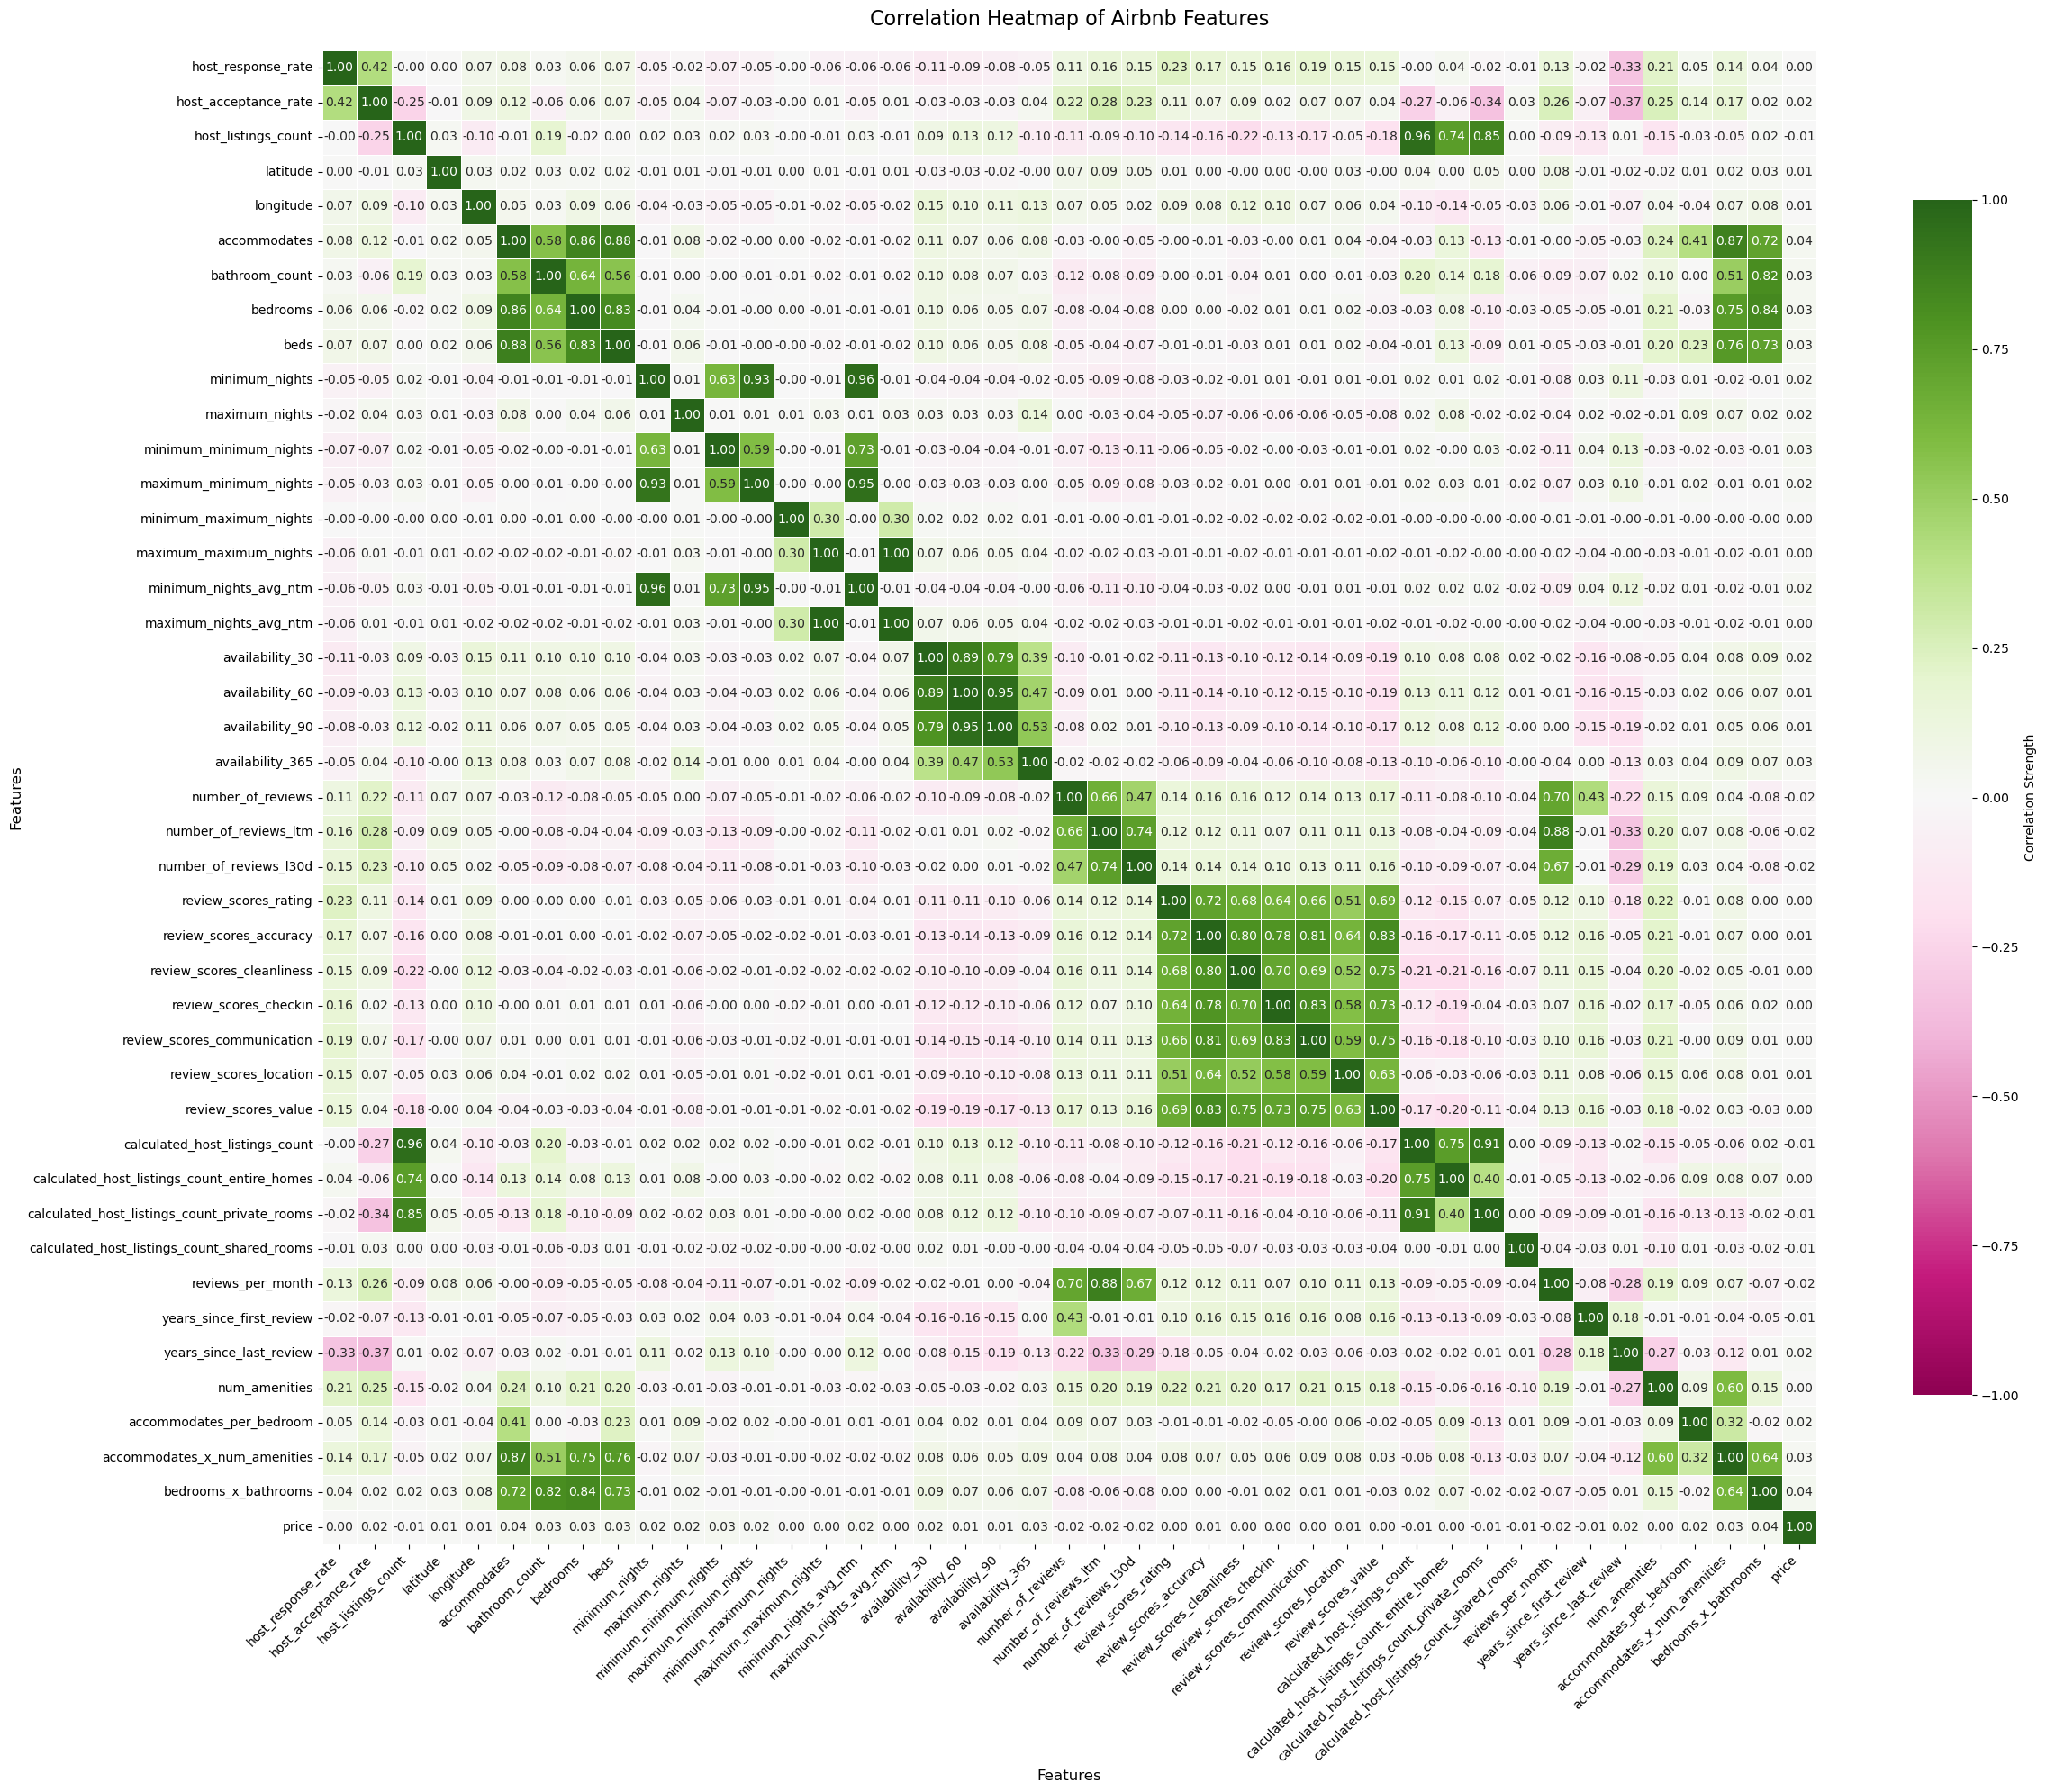

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'host_response_rate','host_acceptance_rate','host_listings_count',
    'latitude','longitude','accommodates','bathroom_count','bedrooms','beds',
    'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90',
    'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
    'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value', 'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms', 'reviews_per_month', 'years_since_first_review',
    'years_since_last_review', 'num_amenities','accommodates_per_bedroom','accommodates_x_num_amenities',
    'bedrooms_x_bathrooms','price'
]

# Compute correlation matrix
correlation_matrix = train_df_unscaled[num_cols].corr()

# Create the heatmap
plt.figure(figsize=(25, 20))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='PiYG',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation Strength"}
)

plt.title("Correlation Heatmap of Airbnb Features", fontsize=16, pad=20)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()





### Correlation Heatmap: Linearity and Modeling Implications

The correlation heatmap reveals that all numerical features have weak linear relationships with price, with the strongest correlations under 0.20. This lack of strong linear associations suggests that simple linear models will not fully capture the factors influencing Airbnb prices. Many effects are likely non-linear or depend on interactions between multiple features.

**Modeling Implications:**  
Given these observations, non-linear modeling approaches—such as gradient boosting machines (e.g., LightGBM, CatBoost) and neural networks (MLP)—are more appropriate for this task. These methods can capture the complex, non-linear patterns and feature interactions that simple linear models would miss. Notably, even engineered features (like `accommodates_x_num_amenities`) have only slightly higher correlations with price compared to their individual components, highlighting the challenge of accurate linear prediction in this dataset.

**Feature-to-feature correlations:**  
- **Property Size & Capacity:** Metrics such as `bedrooms`, `accommodates`, `beds`, and `bathroom_count` are moderately to highly correlated with each other, as expected, since larger properties generally have more rooms and amenities.
- **Review Scores:** There is a visible cluster of strong positive correlations among all review score variables (e.g., `review_scores_rating`, `review_scores_accuracy`, `review_scores_cleanliness`, etc.). This is intuitive—listings that score highly on one aspect of reviews tend to perform well on others, reflecting either overall property quality or positive guest experiences.
- **Minimum/Maximum Nights:** The various minimum and maximum nights variables (`minimum_nights`, `maximum_nights`, and their derivatives) are also strongly correlated with each other. This reflects consistency in booking requirements across different time windows or property policies.
- **Multicollinearity:** While these blocks of features (property size, review scores, and night requirements) are internally correlated, most other features do not display significant multicollinearity, minimizing redundancy concerns for advanced models.

**Summary of Other Findings:**  
Most remaining features—including host metrics and availability measures—have only weak or negligible linear relationships with price. This confirms that price variation in Airbnb listings is largely driven by complex and non-linear factors, validating the use of non-linear machine learning models for price prediction.


Categorical columns: ['ID', 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability', 'instant_bookable', 'verif_email', 'verif_phone', 'verif_work_email', 'verif_count', 'bedrooms_missing', 'beds_missing', 'host_acceptance_rate_missing', 'availability_365_missing', 'minimum_minimum_nights_missing', 'maximum_maximum_nights_missing', 'review_scores_accuracy_missing', 'review_scores_cleanliness_missing', 'review_scores_checkin_missing', 'review_scores_communication_missing', 'review_scores_location_missing', 'review_scores_value_missing', 'host_response_time_missing', 'review_scores_rating_missing', 'first_review_missing', 'last_review_missing', 'reviews_per_month_missing', 'host_response_time_encoded', 'bathroom_type_derived_None_Entire_Listing_0_Bath', 'bathroom_type_derived_Private', 'bathroom_type_derived_Private_Room_Ambiguous_Bathroom', 'bathroom_type_derived_Shared', 'bathroom_type_derived_Unknown', 'property_room_interaction_grouped_Entire home_En

/var/folders/qx/4rypfhxn58g0nwr34j9lv7jc0000gn/T/ipykernel_38480/3127577365.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/qx/4rypfhxn58g0nwr34j9lv7jc0000gn/T/ipykernel_38480/3127577365.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/qx/4rypfhxn58g0nwr34j9lv7jc0000gn/T/ipykernel_38480/3127577365.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/qx/4rypfhxn58g0nwr34j9lv7jc0000gn/T/ipykernel_38480/3127577365.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/qx/4rypfhxn58g0nwr34j9lv7jc0000gn/T/ipykernel_38480/3127577365.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/qx/4rypfhxn58g0nwr34j9lv7jc0000g

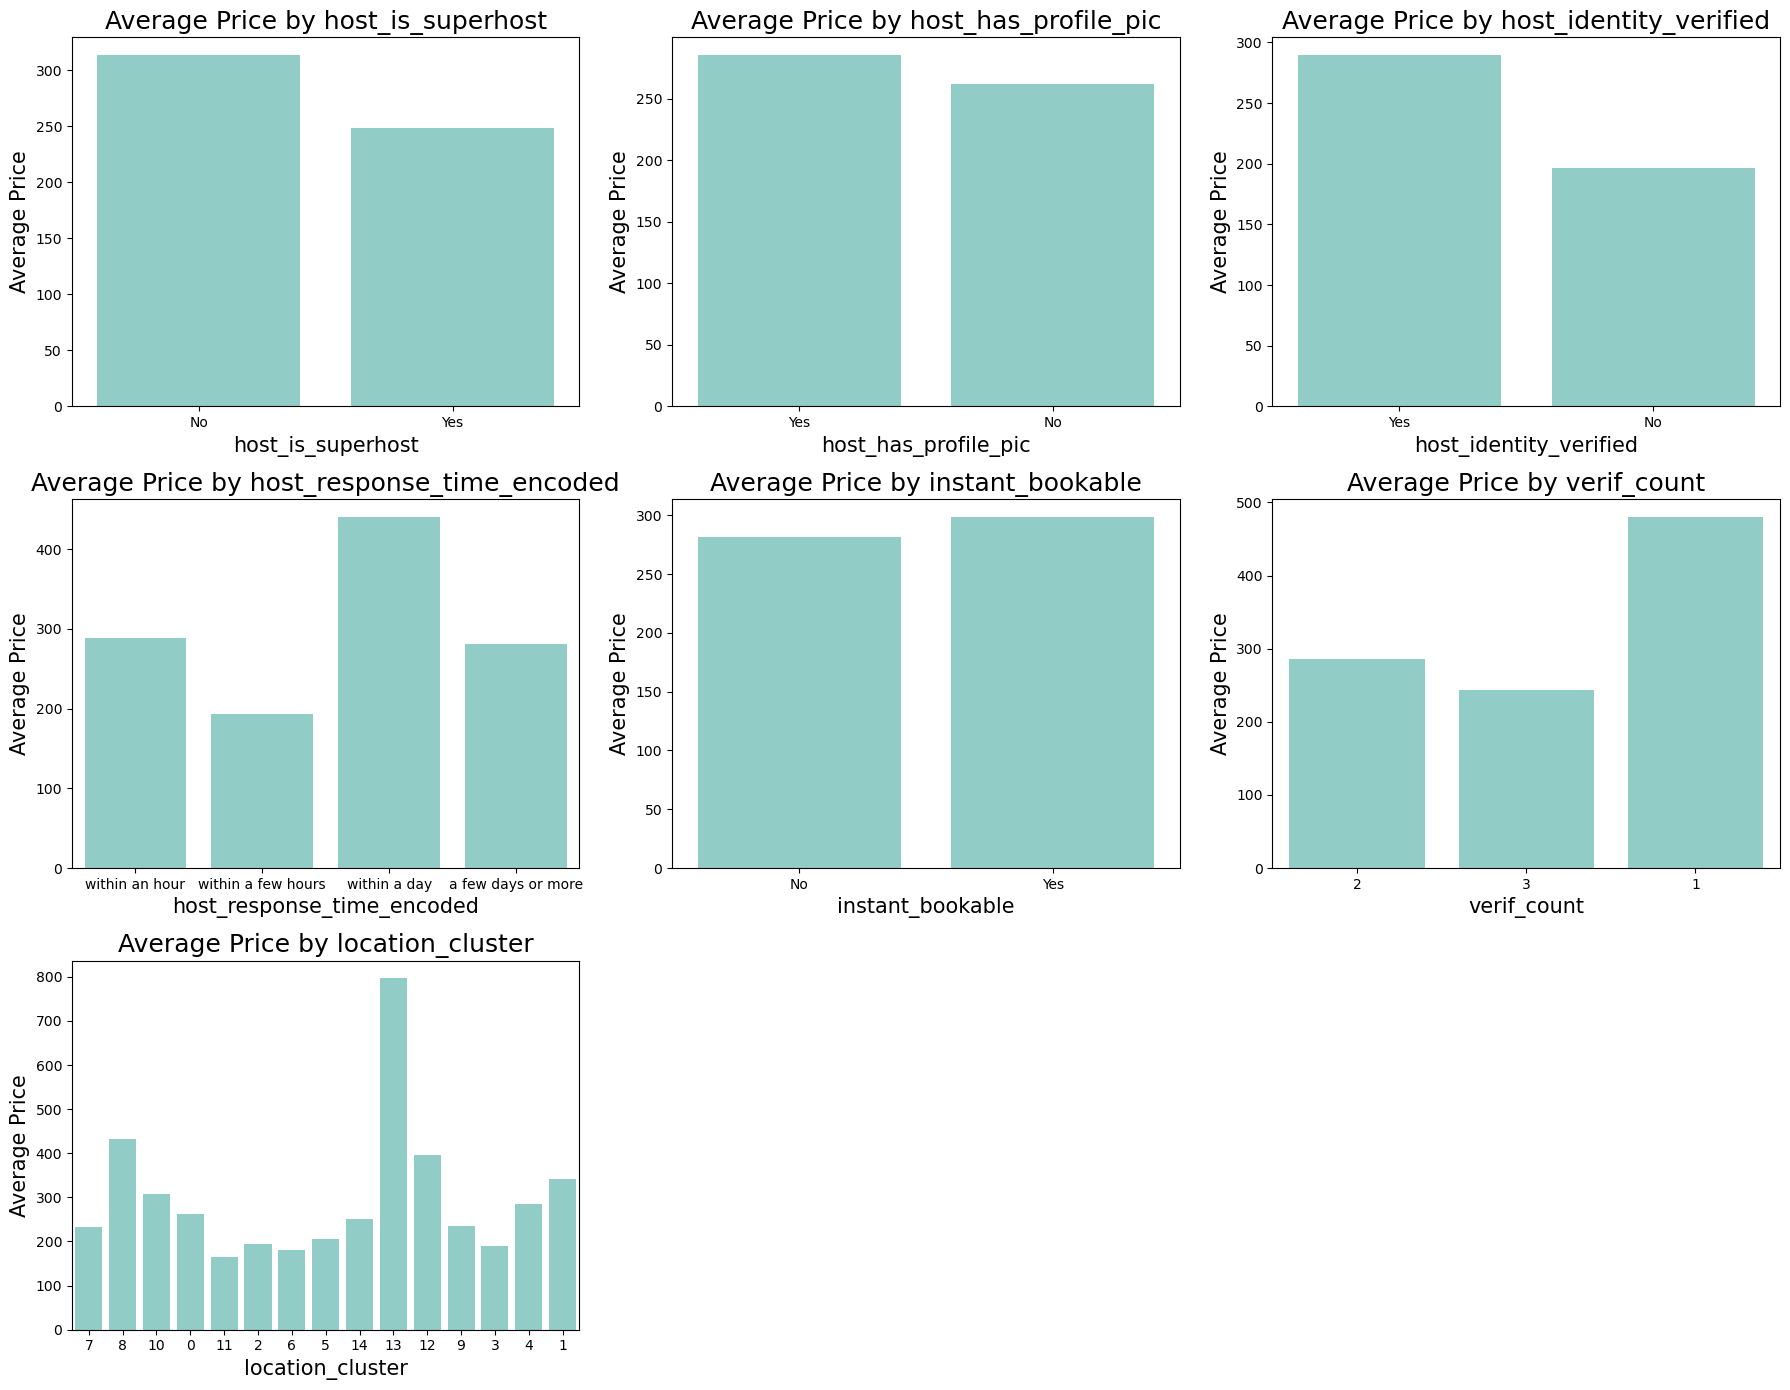

In [102]:
# All columns in the DataFrame
all_cols = list(train_df_unscaled.columns)

# Columns not in num_cols = categorical columns
cat_cols = [col for col in all_cols if col not in num_cols]

print("Categorical columns:", cat_cols)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# choosing the categorical columns to plot, because there are too many encoded categorical columns
cat_cols = [
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
    'host_response_time_encoded', 'instant_bookable', 'verif_count', 'location_cluster'
]

# Define mapping dictionaries for pretty labels
mapping = {
    'host_is_superhost': {0: 'No', 1: 'Yes'},
    'host_has_profile_pic': {0: 'No', 1: 'Yes'},
    'host_identity_verified': {0: 'No', 1: 'Yes'},
    'instant_bookable': {0: 'No', 1: 'Yes'},
    'host_response_time_encoded': {
        0: 'within an hour',
        1: 'within a few hours',
        2: 'within a day',
        3: 'a few days or more'
    },
    'verif_count': {v: str(v) for v in sorted(train_df['verif_count'].unique())},
    'location_cluster': {v: str(v) for v in sorted(train_df['location_cluster'].unique())}
}

# Set up the subplot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    plot_df = train_df.copy()
    # Apply mapping for human-readable labels
    if col in mapping:
        plot_df[f'{col}_label'] = plot_df[col].map(mapping[col])
        x_col = f'{col}_label'
    else:
        x_col = col
    sns.barplot(
        x=x_col,
        y='price',
        data=plot_df,
        estimator=np.mean,
        ci=None,
        ax=axes[i],
        color="#88D6CE",  
    )
    axes[i].set_title(f'Average Price by {col}', fontsize=18)
    axes[i].set_xlabel(col, fontsize=15)
    axes[i].set_ylabel('Average Price', fontsize=15)

# Hide unused axes if less than 9
for j in range(len(cat_cols), 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



## Categorical Feature Analysis: Findings and Rationale

### Why These Categorical Features Were Selected

The selected categorical variables capture core aspects of Airbnb listing quality, host behavior, trust, and location—all expected to influence pricing and guest decisions:

- **Host status and trust:**  
  `host_is_superhost`, `host_has_profile_pic`, and `host_identity_verified` signal trustworthiness and professionalism, which can affect both listing value and booking rates.
- **Booking and availability:**  
  `instant_bookable`, `has_availability`, and `host_response_time_encoded` reflect booking ease and responsiveness, potentially impacting guest preference and price competitiveness.
- **Verification and clustering:**  
  `verif_count` (number of verifications) and `location_cluster` (engineered spatial group) capture additional trust signals and geographic effects on price.

These features were chosen because they are theoretically important in platform-based rental markets and are commonly used by guests to filter and assess listings.

---

### Key EDA Findings from Barplots

1. **Host Status & Trust Features:**
   - **Superhost status:** Superhost listings do not command higher average prices; in this sample, they are sometimes associated with lower prices, possibly reflecting a focus on high-turnover or budget properties.
   - **Profile picture:** Listings with a host profile picture do not show a significant price premium.
   - **Identity verified:** Verified hosts' listings have lower average prices, suggesting verification alone may not drive higher prices.

2. **Booking and Availability:**
   - **Instant bookable:** Instant bookable listings tend to have slightly higher average prices, reflecting guest convenience.
   - **Host response time:** The highest average prices are for listings with a "within a day" response, while slower or much faster response times have lower averages.
   - **Verification count:** Listings with a verification count of “1” show higher average prices than those with more verifications.

3. **Location Clustering:**
   - **Location cluster:** Clear spatial price variation is observed, with some clusters (e.g., cluster 13) achieving much higher average prices. This suggests that neighborhood or proximity to key areas has a substantial impact on price.

---

### Summary

While some categorical factors (like instant bookability and location cluster) are associated with higher prices, others (such as superhost status or verification) do not guarantee a price premium and may interact with other listing features. **Location cluster** in particular demonstrates the greatest price differentiation, underscoring the importance of geography in Airbnb pricing. These categorical features were selected for their relevance to both guest behavior and market theory, and the visualizations confirm that several have meaningful, though sometimes complex, relationships with price.


In [ ]:
import folium
import matplotlib
from matplotlib import cm, colors

colormap_name = 'plasma' 
cmap = cm.get_cmap(colormap_name)

# Winsorisation to exclude to top 1 percent of prices, for better colour visibility

lower = train_df_unscaled['price'].quantile(0.00) # we only want to exclude the top 1 percent
upper = train_df_unscaled['price'].quantile(0.99)
norm = colors.Normalize(vmin=lower, vmax=upper)

center = [train_df_unscaled['latitude'].mean(), train_df_unscaled['longitude'].mean()]
m = folium.Map(location=center, zoom_start=12)

for _, row in train_df_unscaled.sample(min(1000, len(train_df_unscaled))).iterrows():
    # Clamp the price to the normalization range to avoid colorwash from outliers
    price_for_color = np.clip(row['price'], lower, upper)
    rgba = cmap(norm(price_for_color))
    hex_color = matplotlib.colors.rgb2hex(rgba)
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=hex_color,
        fill=True,
        fill_color=hex_color,
        fill_opacity=0.8,
        popup=f"Price: ${row['price']:.0f}"
    ).add_to(m)

m


/var/folders/qx/4rypfhxn58g0nwr34j9lv7jc0000gn/T/ipykernel_38480/459956700.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(colormap_name)


### Spatial Price Distribution of Melbourne Airbnb Listings

The map above visualises the spatial distribution of Airbnb prices across Melbourne, with each listing shown as a colored circle plotted at its true latitude and longitude. The color of each point reflects its price: lower-priced listings appear as dark purple, while higher-priced listings transition through orange to bright yellow, according to the plasma colormap.

To ensure that color differences are meaningful and not distorted by a small number of extreme outliers, we applied **winsorisation**: only the single highest-priced listing was excluded from the color mapping. This approach enhances the contrast and interpretability of the map, allowing the majority of prices to be clearly distinguished.

**Key observations:**
- **Higher-priced properties (yellow/orange dots)** are clustered in and around the inner city, as well as certain affluent suburbs and coastal areas.
- **Lower-priced properties (purple dots)** are more widely distributed throughout the metropolitan region and outer suburbs.
- This spatial pattern highlights the importance of location as a driver of Airbnb prices in Melbourne, with premium prices concentrated near the city centre and desirable neighborhoods.

Overall, the winsorised color scaling provides a high-contrast, intuitive view of how listing prices vary geographically, supporting both EDA insights and feature engineering for predictive modeling.


## 8. Model Selection

## Selected Regression Models

### 1. LightGBM Regressor
LightGBM (Light Gradient Boosting Machine) is an efficient gradient boosting framework based on decision trees. It is designed for fast computation and low memory usage, making it ideal for large, high-dimensional datasets like ours. LightGBM excels at handling both numerical and categorical features, and is particularly good at capturing complex, non-linear relationships through its ensemble of decision trees. Its robustness to outliers and support for advanced features such as early stopping and regularization further make it a top choice for predictive tasks in tabular data.

### 2. CatBoost Regressor
CatBoost is another advanced gradient boosting library that is especially effective for datasets with many categorical features. It automatically handles categorical variables without the need for manual encoding, reducing the risk of data leakage and overfitting. CatBoost uses ordered boosting and sophisticated regularization to deliver strong performance even with smaller datasets or unbalanced features. In this competition, CatBoost is valuable for its ability to efficiently utilize the dataset’s encoded categorical and engineered features, potentially capturing interactions that other models might miss.

### 3. Multi-Layer Perceptron (MLP) Regressor
The MLP Regressor is a type of artificial neural network capable of learning complex, non-linear mappings between input features and the target variable. Unlike tree-based methods, the MLP models relationships through interconnected layers of neurons, making it suitable for capturing interactions that are not easily handled by ensembles of decision trees. Using an MLP alongside LightGBM and CatBoost allows for a comparison between tree-based ensemble models and a deep learning approach, providing diversity in modeling techniques and possibly improving predictive performance through ensembling.

---
### Additional Models Explored

In addition to the three primary models, two additional regression algorithms were also trained and evaluated for comparison:

- **XGBoost Regressor:**  
  XGBoost is another highly popular gradient boosting framework. It is known for its regularization capabilities, scalability, and consistently strong performance in structured data competitions. XGBoost provides robust handling of missing values and offers flexible tuning options, making it valuable as a benchmark model for this prediction task.

- **Extra Trees Regressor:**  and **Random Forest**
  Both models are an ensemble method that fits multiple randomized decision trees on the dataset and averages their predictions. Unlike gradient boosting, Extra Trees focuses on variance reduction and randomness to prevent overfitting. It provides a useful alternative perspective, especially in identifying feature importance and as a component for potential model ensembling.

While these models were not selected as the main 3 models, their inclusion ensured a more comprehensive model comparison and provided insights that informed hyperparameter tuning and ensembling strategies.

---

### Why These Models Were Chosen

These three models represent the most effective and commonly used algorithms for tabular data prediction:
- **LightGBM and CatBoost** are both state-of-the-art gradient boosting algorithms, excelling with structured data and feature engineering.
- **MLP Regressor** introduces a fundamentally different (neural network) approach, capturing complex, high-order interactions.

Together, they provide a strong, diverse modeling toolkit for the Airbnb price prediction task.

---






## 9. Model Training & Evaluation

### Baseline Models (Cross-Validation)

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error

# Split features and target
X = train_df.drop(columns=['price'])
y = train_df['price']

# Train/validation split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)


# -----------------------------
# Baseline Model: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_valid)
lr_rmse = mean_absolute_error(y_valid, lr_preds )
print(f"Linear Regression RMSE: {lr_rmse:.4f}")

# -----------------------------
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_valid)
rf_rmse = mean_absolute_error(y_valid, rf_preds)
print(f"Random Forest RMSE: {rf_rmse:.4f}")

# -----------------------------
# LightGBM - MAE objective
lgb = LGBMRegressor(objective='regression_l1', n_estimators=100, random_state=42)
lgb.fit(X_train, y_train)
lgb_preds = lgb.predict(X_valid)
lgb_mae = mean_absolute_error(y_valid, lgb_preds)
print(f"LightGBM MAE: {lgb_mae:.4f}")

# ------------------------
# XGBoost - MAE objective
xgb = XGBRegressor(objective='reg:absoluteerror', n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_valid)
xgb_mae = mean_absolute_error(y_valid, xgb_preds)
print(f"XGBoost MAE: {xgb_mae:.4f}")

# ------------------------
# CatBoost - MAE loss
cat = CatBoostRegressor(loss_function='MAE', verbose=0, n_estimators=100, random_state=42)
cat.fit(X_train, y_train)
cat_preds = cat.predict(X_valid)
cat_mae = mean_absolute_error(y_valid, cat_preds)
print(f"CatBoost MAE: {cat_mae:.4f}")
 # -----------------------------


Linear Regression RMSE: 299.7263
Random Forest RMSE: 157.5329
LightGBM MAE: 91.3741
XGBoost MAE: 93.4642
CatBoost MAE: 102.5929


In [105]:
from sklearn.model_selection import KFold
# Apply log1p transform to target
y = np.log1p(train_df['price'])
X = train_df.drop(columns=['price', 'ID'])  # Ensure 'ID' is dropped if it exists

def evaluate_model(model, X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    maes = []

    for train_idx, valid_idx in kf.split(X):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_valid)
        y_pred = np.expm1(y_pred_log)
        y_valid_exp = np.expm1(y_valid)

        mae = mean_absolute_error(y_valid_exp, y_pred)
        maes.append(mae)

    return np.mean(maes)

models = {
    "XGBoost": XGBRegressor(objective='reg:absoluteerror', n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(objective='regression_l1', n_estimators=100, random_state=42),
    "CatBoost": CatBoostRegressor(loss_function='MAE', verbose=0, n_estimators=100, random_state=42)
}

# Store scores
model_scores = {}
for name, model in models.items():
    score = evaluate_model(model, X, y)
    model_scores[name] = score
    print(f"{name} MAE (CV): {score:.4f}")

# Pick best model
best_model_name = min(model_scores, key=model_scores.get)
print(f"Best model: {best_model_name}")
best_model = models[best_model_name]

# Prepare test features by dropping ID column
if 'ID' in test_df.columns:
    X_test = test_df.drop(columns=['ID'])
else:
    X_test = test_df.copy()

# Predict on test set (ensure test_df is clean and preprocessed)
final_preds_log = best_model.predict(X_test)
final_preds_log = np.clip(final_preds_log, a_min=None, a_max=20)  # Optional: prevent explosion
final_preds = np.expm1(final_preds_log)

# Ensure 'ID' is still in test_df
if 'ID' not in test_df.columns:
    raise ValueError("Column 'ID' is missing from test_df. Can't create submission.")

submission = pd.DataFrame({
    'ID': test_df['ID'],
    'price': final_preds
})
submission.to_csv('submission.csv', index=False)


XGBoost MAE (CV): 120.7603
LightGBM MAE (CV): 119.3207
CatBoost MAE (CV): 131.1671
Best model: LightGBM


### LightGBM — Optuna Tuning

In [106]:
""""
import optuna

X = train_df.drop(columns=['price',"ID"])
y = np.log1p(train_df['price'])  # log-transform target

# Tuning LightGBM hyperparameters using Optuna
def objective_lgb(trial):
    params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 80, 120),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 15, 30),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1': trial.suggest_float('lambda_l1', 0, 5),
        'lambda_l2': trial.suggest_float('lambda_l2', 0, 5),
        'random_state': 42,
        'verbosity': -1,  # Keep here only if you don't add it to constructor
     
    }
    # KFold cross-validation
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    val_maes = []

    for train_idx, val_idx in kf.split(X):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        model = LGBMRegressor(
            **params,
           n_estimators=1000,
            
        )
        model.fit(
            X_train_cv, y_train_cv,
            eval_set=[(X_val_cv, y_val_cv)],
            eval_metric='mae',
            callbacks=[lgb.early_stopping(stopping_rounds=50)],
        )

        y_pred_log = model.predict(X_val_cv)
        y_pred = np.expm1(y_pred_log)  # inverse log transform
        y_true = np.expm1(y_val_cv)

        val_mae = mean_absolute_error(y_true, y_pred)
        val_maes.append(val_mae)

    return np.mean(val_maes)

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=50)  # Adjust trials as needed

print('Best params:', study_lgb.best_params)
print('Best CV MAE:', study_lgb.best_value)
"""

'"\nimport optuna\n\nX = train_df.drop(columns=[\'price\',"ID"])\ny = np.log1p(train_df[\'price\'])  # log-transform target\n\n# Tuning LightGBM hyperparameters using Optuna\ndef objective_lgb(trial):\n    params = {\n        \'objective\': \'regression_l1\',\n        \'metric\': \'mae\',\n        \'verbosity\': -1,\n        \'boosting_type\': \'gbdt\',\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.01, 0.05, log=True),\n        \'num_leaves\': trial.suggest_int(\'num_leaves\', 80, 120),\n        \'max_depth\': trial.suggest_int(\'max_depth\', 5, 12),\n        \'min_data_in_leaf\': trial.suggest_int(\'min_data_in_leaf\', 15, 30),\n        \'feature_fraction\': trial.suggest_float(\'feature_fraction\', 0.6, 1.0),\n        \'bagging_fraction\': trial.suggest_float(\'bagging_fraction\', 0.6, 1.0),\n        \'bagging_freq\': trial.suggest_int(\'bagging_freq\', 1, 10),\n        \'lambda_l1\': trial.suggest_float(\'lambda_l1\', 0, 5),\n        \'lambda_l2\': trial.sugge

### LightGBM — Final Model

In [107]:
from lightgbm import LGBMRegressor, early_stopping
# light gbm with best params from Optuna
# Data
X = train_df.drop(columns=['price', 'ID'])  # Ensure 'ID' is dropped if it exists
y = np.log1p(train_df['price'])  # Log-transform the target

# Use best params from Optuna (replace with your actual best params if different)
best_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 90,
    'max_depth': 7,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.75,
    'bagging_fraction': 0.65,
    'bagging_freq': 5,
    'lambda_l1': 1.5,
    'lambda_l2': 1.0,
    'random_state': 42,
    'verbosity': -1
}


# Cross-validation to get average MAE on training data
kf = KFold(n_splits=10, shuffle=True, random_state=42)
val_maes = []

for train_idx, val_idx in kf.split(X):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    model = LGBMRegressor(**best_params, n_estimators=1000)
    model.fit(
    X_train_cv, y_train_cv,
    eval_set=[(X_val_cv, y_val_cv)],
    eval_metric='mae',
    callbacks=[early_stopping(stopping_rounds=50)],
)

    y_pred_log = model.predict(X_val_cv)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_val_cv)

    val_mae = mean_absolute_error(y_true, y_pred)
    val_maes.append(val_mae)

print(f"Cross-validated MAE: {np.mean(val_maes):.4f}")


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[854]	valid_0's l1: 0.208514
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[958]	valid_0's l1: 0.212012
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's l1: 0.220651
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l1: 0.229679
Training until validation scores don't improve for 50 rounds


KeyboardInterrupt: 

In [ ]:
## Export to submission file
# Fit final model on all training data
final_model = LGBMRegressor(**best_params, n_estimators=1000)
final_model.fit(X, y)

# Save the trained model
import pickle
#with open('final_lgbm_model.pkl', 'wb') as f:
#    pickle.dump(final_model, f)

# Predict on test set (already preprocessed)
final_preds_log = final_model.predict(test_df.drop(columns=['ID']))
final_preds = np.expm1(final_preds_log)  # Inverse log transform

# Save predictions
submission = pd.DataFrame({
    'ID': test_df['ID'],  # Replace with actual ID column name
    'price': final_preds
})
submission.to_csv('submission_lgbm.csv', index=False)

print("Submission file saved as 'submission_lgbm.csv'")



Submission file saved as 'submission_lgbm.csv'


### XGBoost — Optuna Tuning

In [ ]:
"""
# xgboost with Optuna
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 200, 300]),
        'max_depth': trial.suggest_categorical('max_depth', [4, 6, 8]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.01, 0.05, 0.1]),
        'subsample': trial.suggest_categorical('subsample', [0.7, 0.8, 1.0]),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.7, 0.8, 1.0]),
        'reg_alpha': trial.suggest_categorical('reg_alpha', [0, 0.1, 1]),    # L1
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1, 5, 10]),   # L2
        'objective': 'reg:absoluteerror',
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'mae',
        'verbosity': 0
    }
    # KFold cross-validation
    kf = KFold(n_splits=15, shuffle=True, random_state=42)
    maes = []
    for train_idx, val_idx in kf.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
        model = XGBRegressor(**params)
        model.fit(
            X_train_cv, y_train_cv,
            eval_set=[(X_val_cv, y_val_cv)],
            
            verbose=False
        )
        y_pred_log = model.predict(X_val_cv)
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_val_cv)
        mae = mean_absolute_error(y_true, y_pred)
        maes.append(mae)
    return np.mean(maes)

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50)  # Increase n_trials for deeper search

print("Best Parameters:", study_xgb.best_params)
print("Best CV MAE:", study_xgb.best_value)

"""

'\n# xgboost with Optuna\ndef objective_xgb(trial):\n    params = {\n        \'n_estimators\': trial.suggest_categorical(\'n_estimators\', [100, 200, 300]),\n        \'max_depth\': trial.suggest_categorical(\'max_depth\', [4, 6, 8]),\n        \'learning_rate\': trial.suggest_categorical(\'learning_rate\', [0.01, 0.05, 0.1]),\n        \'subsample\': trial.suggest_categorical(\'subsample\', [0.7, 0.8, 1.0]),\n        \'colsample_bytree\': trial.suggest_categorical(\'colsample_bytree\', [0.7, 0.8, 1.0]),\n        \'reg_alpha\': trial.suggest_categorical(\'reg_alpha\', [0, 0.1, 1]),    # L1\n        \'reg_lambda\': trial.suggest_categorical(\'reg_lambda\', [1, 5, 10]),   # L2\n        \'objective\': \'reg:absoluteerror\',\n        \'random_state\': 42,\n        \'n_jobs\': -1,\n        \'eval_metric\': \'mae\',\n        \'verbosity\': 0\n    }\n    # KFold cross-validation\n    kf = KFold(n_splits=15, shuffle=True, random_state=42)\n    maes = []\n    for train_idx, val_idx in kf.split(X, 

### XGBoost — Final Model

In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold


# Prepare features and target
X = train_df.drop(columns=['price', 'ID'])
y = np.log1p(train_df['price'])  # log-transform target

# XGBoost hyperparameters (adjust as needed)
xgb_params = {
    'objective': 'reg:absoluteerror',
    'eval_metric': 'mae',
    'eta': 0.03,
    'max_depth': 7,
    'subsample': 0.65,
    'colsample_bytree': 0.75,
    'min_child_weight': 1,
    'reg_alpha': 1.5,
    'reg_lambda': 1.0,
    'seed': 42,
    'verbosity': 0
}

# --- 5-Fold Cross-validation ---
kf = KFold(n_splits=10, shuffle=True, random_state=42)
val_maes = []
models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"--- Fold {fold+1} ---")
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBRegressor(**xgb_params, n_estimators=1000, early_stopping_rounds=50)
    model.fit(
        X_train_cv, y_train_cv,
        eval_set=[(X_val_cv, y_val_cv)],
        verbose=False
    )

    y_pred_log = model.predict(X_val_cv)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_val_cv)

    val_mae = mean_absolute_error(y_true, y_pred)
    print(f"Fold {fold+1} MAE: {val_mae:.4f}")
    val_maes.append(val_mae)
    models.append(model)

print(f"\nCross-validated MAE: {np.mean(val_maes):.4f} (+/- {np.std(val_maes):.4f})")

# --- Train final model on all training data ---
final_model = xgb.XGBRegressor(**xgb_params, n_estimators=1000)
final_model.fit(X, y)

# --- Predict on test set ---
test_ids = test_df['ID']
X_test = test_df.drop(columns=['ID'])

final_preds_log = final_model.predict(X_test)
final_preds = np.expm1(final_preds_log)  # inverse log1p

# --- Save submission ---
submission_df = pd.DataFrame({
    'ID': test_ids,
    'price': final_preds
})
submission_df.to_csv('submission_xgboost.csv', index=False)

print("Submission file saved as 'submission_xgboost.csv'")

--- Fold 1 ---
Fold 1 MAE: 64.7450
--- Fold 2 ---
Fold 2 MAE: 110.6020
--- Fold 3 ---
Fold 3 MAE: 54.7305
--- Fold 4 ---
Fold 4 MAE: 57.6927
--- Fold 5 ---
Fold 5 MAE: 89.1029
--- Fold 6 ---
Fold 6 MAE: 135.2395
--- Fold 7 ---
Fold 7 MAE: 227.9476
--- Fold 8 ---
Fold 8 MAE: 89.6978
--- Fold 9 ---
Fold 9 MAE: 269.9567
--- Fold 10 ---
Fold 10 MAE: 61.6056

Cross-validated MAE: 116.1321 (+/- 71.2663)
Submission file saved as 'submission_xgboost.csv'


### CatBoost — Optuna Tuning

In [ ]:
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np
"""
# Split data for tuning
X_train_cb, X_valid_cb, y_train_cb, y_valid_cb = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Objective function for CatBoost hyperparameter tuning
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 150, 400),
        'depth': trial.suggest_int('depth', 4, 10),  # Fixed to correct syntax
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 1),
        'loss_function': 'MAE',
        'eval_metric': 'MAE',
        'random_seed': 42,
        'verbose': 0
    }
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    val_maes = []
    for train_idx, val_idx in kf.split(X):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
        model = CatBoostRegressor(**params)
        model.fit(
            X_train_cv, y_train_cv,
            eval_set=(X_val_cv, y_val_cv),
            early_stopping_rounds=30,
            use_best_model=True
        )
        y_pred_log = model.predict(X_val_cv)
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_val_cv)
        val_mae = mean_absolute_error(y_true, y_pred)
        val_maes.append(val_mae)
    return np.mean(val_maes)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)  # Increase n_trials for wider search

print("Best params:", study.best_trial.params)
print("Best MAE:", study.best_value)
"""


'\n# Split data for tuning\nX_train_cb, X_valid_cb, y_train_cb, y_valid_cb = train_test_split(\n    X, y, test_size=0.2, random_state=42\n)\n\n\n# Objective function for CatBoost hyperparameter tuning\ndef objective(trial):\n    params = {\n        \'iterations\': trial.suggest_int(\'iterations\', 150, 400),\n        \'depth\': trial.suggest_int(\'depth\', 4, 10),  # Fixed to correct syntax\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.01, 0.2, log=True),\n        \'l2_leaf_reg\': trial.suggest_float(\'l2_leaf_reg\', 1e-2, 10.0, log=True),\n        \'bagging_temperature\': trial.suggest_float(\'bagging_temperature\', 0, 1),\n        \'random_strength\': trial.suggest_float(\'random_strength\', 0, 1),\n        \'loss_function\': \'MAE\',\n        \'eval_metric\': \'MAE\',\n        \'random_seed\': 42,\n        \'verbose\': 0\n    }\n    kf = KFold(n_splits=10, shuffle=True, random_state=42)\n    val_maes = []\n    for train_idx, val_idx in kf.split(X):\n        X_

### CatBoost — Final Model

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import numpy as np


# Use all features and log-transformed target as before
X = train_df.drop(columns=['price', 'ID'])
y = np.log1p(train_df['price'])
# cat boost hyperparameters based on Optuna tuning
best_cb_params = {
    'iterations': 2500,
    'learning_rate': 0.04,
    'depth': 7,
    'l2_leaf_reg': 3,
    'colsample_bylevel': 0.8,
    'border_count': 128,
    'random_strength': 1,
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42, # For reproducibility
    'verbose': 100, # Print info every 100 iterations
    'early_stopping_rounds': 50
    # 'cat_features': [list_of_your_categorical_feature_indices_or_names] # CRITICAL
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)
val_maes = []

for train_idx, val_idx in kf.split(X):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostRegressor(**best_cb_params)
    model.fit(
        X_train_cv, y_train_cv,
        eval_set=(X_val_cv, y_val_cv),
        early_stopping_rounds=50,
        verbose=0
    )

    y_pred_log = model.predict(X_val_cv)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_val_cv)

    val_mae = mean_absolute_error(y_true, y_pred)
    val_maes.append(val_mae)

print(f"Cross-validated MAE (CatBoost): {np.mean(val_maes):.4f}")

# 1. Retrain on ALL training data
final_cb = CatBoostRegressor(**best_cb_params)
final_cb.fit(X, y, verbose=100)

# 2. Predict on the test set
cb_test_pred_log = final_cb.predict(X_test)
cb_test_pred = np.expm1(cb_test_pred_log)  # Reverse log1p

# 3. Export predictions for Kaggle
results_cb = pd.DataFrame({
    'ID': test_df['ID'],
    'Predicted_Price': cb_test_pred
})
results_cb.to_csv('catboost_allfeatures_predictions.csv', index=False)
print("CatBoost predictions saved as 'catboost_allfeatures_predictions.csv'")


Cross-validated MAE (CatBoost): 116.1177
0:	learn: 0.5081892	total: 3.66ms	remaining: 9.14s
100:	learn: 0.2492017	total: 301ms	remaining: 7.15s
200:	learn: 0.2138541	total: 607ms	remaining: 6.94s
300:	learn: 0.1928397	total: 948ms	remaining: 6.93s
400:	learn: 0.1778080	total: 1.26s	remaining: 6.62s
500:	learn: 0.1657746	total: 1.57s	remaining: 6.25s
600:	learn: 0.1568173	total: 1.86s	remaining: 5.88s
700:	learn: 0.1496061	total: 2.16s	remaining: 5.54s
800:	learn: 0.1436445	total: 2.46s	remaining: 5.23s
900:	learn: 0.1386376	total: 2.76s	remaining: 4.89s
1000:	learn: 0.1343479	total: 3.05s	remaining: 4.57s
1100:	learn: 0.1307152	total: 3.34s	remaining: 4.25s
1200:	learn: 0.1272130	total: 3.63s	remaining: 3.93s
1300:	learn: 0.1243100	total: 3.93s	remaining: 3.62s
1400:	learn: 0.1215409	total: 4.29s	remaining: 3.36s
1500:	learn: 0.1192993	total: 4.59s	remaining: 3.06s
1600:	learn: 0.1168265	total: 4.88s	remaining: 2.74s
1700:	learn: 0.1147719	total: 5.18s	remaining: 2.43s
1800:	learn: 0.1

### MLP + PCA — Optuna Tuning

In [ ]:
# tune with Optuna

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

"""
# Use all features and log-transformed target
X = train_df.drop(columns=['price', 'ID'])
y = np.log1p(train_df['price'])

def objective(trial):
    # PCA hyperparameter
    n_components = trial.suggest_int('n_components', 5, min(20, X.shape[1]))
    
    # MLP hyperparameters with Optuna
    hidden_layer_sizes = trial.suggest_categorical('hidden_layer_sizes', [(32,), (64,), (32,16), (64,16)])
    alpha = trial.suggest_float('alpha', 0.01, 0.2, log=True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 3e-3, log=True)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    max_iter = trial.suggest_int('max_iter', 150, 300)
    
    mlp_params = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'alpha': alpha,
        'learning_rate_init': learning_rate_init,
        'activation': activation,
        'batch_size': batch_size,
        'solver': 'adam',
        'early_stopping': True,
        'random_state': 42,
        'max_iter': max_iter
    }
    
    kf = KFold(n_splits=15, shuffle=True, random_state=42)
    val_maes = []
    for train_idx, val_idx in kf.split(X):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
        
        pipe = Pipeline([
            ("pca", PCA(n_components=n_components, random_state=42)),
            ("mlp", MLPRegressor(**mlp_params))
        ])
        pipe.fit(X_train_cv, y_train_cv)
        y_pred = pipe.predict(X_val_cv)
        val_mae = mean_absolute_error(y_val_cv, y_pred)
        val_maes.append(val_mae)
    return np.mean(val_maes)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)
print("Best params:", study.best_trial.params)
print("Best CV MAE:", study.best_value)

# Print only PCA params
pca_keys = ['n_components']
pca_params = {k: v for k, v in study.best_trial.params.items() if k in pca_keys}
print("Best PCA Params:", pca_params)

# Print only MLP params
mlp_params = {k: v for k, v in study.best_trial.params.items() if k not in pca_keys}
print("Best MLP Params:", mlp_params)
"""

'\n# Use all features and log-transformed target\nX = train_df.drop(columns=[\'price\', \'ID\'])\ny = np.log1p(train_df[\'price\'])\n\ndef objective(trial):\n    # PCA hyperparameter\n    n_components = trial.suggest_int(\'n_components\', 5, min(20, X.shape[1]))\n    \n    # MLP hyperparameters with Optuna\n    hidden_layer_sizes = trial.suggest_categorical(\'hidden_layer_sizes\', [(32,), (64,), (32,16), (64,16)])\n    alpha = trial.suggest_float(\'alpha\', 0.01, 0.2, log=True)\n    learning_rate_init = trial.suggest_float(\'learning_rate_init\', 1e-4, 3e-3, log=True)\n    activation = trial.suggest_categorical(\'activation\', [\'relu\', \'tanh\'])\n    batch_size = trial.suggest_categorical(\'batch_size\', [32, 64])\n    max_iter = trial.suggest_int(\'max_iter\', 150, 300)\n    \n    mlp_params = {\n        \'hidden_layer_sizes\': hidden_layer_sizes,\n        \'alpha\': alpha,\n        \'learning_rate_init\': learning_rate_init,\n        \'activation\': activation,\n        \'batch_si

### MLP + PCA — Final Model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import KernelPCA
from sklearn.pipeline import Pipeline

# --- Prepare data ---
X = train_df.drop(columns=['price', 'ID'])
y = np.log1p(train_df['price'])
X_test = test_df[X.columns]

# --- Manually insert your best PCA and MLP params here ---
pca_params = {
    'n_components': 48,
    'random_state': 42
}

mlp_params = {
    'hidden_layer_sizes':64,
    'alpha': 0.07927179799279559,
    'learning_rate_init': 0.00019678986949703278,
    'activation': 'tanh',
    'batch_size': 32,
    'solver': 'adam',
    'early_stopping': True,
    'random_state': 42,
    'max_iter': 279
}

final_pipe = Pipeline([
    ("pca", PCA(**pca_params)),
    ("mlp", MLPRegressor(**mlp_params))
])

# --- KFold Cross-Validation ---
n_splits = 15
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
val_maes = []

print("MLPRegressor + PCA KFold CV results:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    final_pipe.fit(X_train_cv, y_train_cv)
    y_pred_log = final_pipe.predict(X_val_cv)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_val_cv)
    val_mae = mean_absolute_error(y_true, y_pred)
    val_maes.append(val_mae)
    print(f"Fold {fold} MAE: {val_mae:.4f}")
print(f"\nAverage Cross-validated MAE (MLP + PCA): {np.mean(val_maes):.4f}")

# --- Retrain on ALL data and predict test set ---
final_pipe.fit(X, y)
mlp_test_pred_log = final_pipe.predict(X_test)
mlp_test_pred = np.expm1(mlp_test_pred_log)

# --- Export for Kaggle ---
results_mlp = pd.DataFrame({
    'ID': test_df['ID'],
    'price': mlp_test_pred
})
results_mlp.to_csv('mlp_pca_predictions.csv', index=False)
print("MLP + PCA predictions saved as 'mlp_pca_predictions.csv'")



MLPRegressor + PCA KFold CV results:
Fold 1 MAE: 88.5912
Fold 2 MAE: 72.7888
Fold 3 MAE: 147.3981
Fold 4 MAE: 75.7052
Fold 5 MAE: 66.9345
Fold 6 MAE: 70.5977
Fold 7 MAE: 84.7763
Fold 8 MAE: 228.0046
Fold 9 MAE: 62.5495
Fold 10 MAE: 297.6465
Fold 11 MAE: 142.9632
Fold 12 MAE: 76.5717
Fold 13 MAE: 395.7195
Fold 14 MAE: 64.4165
Fold 15 MAE: 78.9433

Average Cross-validated MAE (MLP + PCA): 130.2404
MLP + PCA predictions saved as 'mlp_pca_predictions.csv'


### Extra Trees — Optuna Tuning

In [ ]:
import optuna
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import numpy as np
"""
X = train_df.drop(columns=['price', 'ID'])
y = np.log1p(train_df['price'])

# Extra Trees Regressor hyperparameter tuning with Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # LOWER for tuning!
        'max_depth': trial.suggest_int('max_depth', 7, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 6),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'n_jobs': -1,
        'random_state': 42
    }
    kf = KFold(n_splits=3, shuffle=True, random_state=42)  # Lower fold for speed
    val_maes = []
    for train_idx, val_idx in kf.split(X):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
        model = ExtraTreesRegressor(**params)
        model.fit(X_train_cv, y_train_cv)
        y_pred = model.predict(X_val_cv)
        val_maes.append(mean_absolute_error(y_val_cv, y_pred))
    return np.mean(val_maes)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)  # 20–40 is enough!

print('Best params:', study.best_params)
print('Best CV MAE:', study.best_value)


"""


"\nX = train_df.drop(columns=['price', 'ID'])\ny = np.log1p(train_df['price'])\n\n# Extra Trees Regressor hyperparameter tuning with Optuna\ndef objective(trial):\n    params = {\n        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # LOWER for tuning!\n        'max_depth': trial.suggest_int('max_depth', 7, 15),\n        'min_samples_split': trial.suggest_int('min_samples_split', 2, 6),\n        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),\n        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),\n        'n_jobs': -1,\n        'random_state': 42\n    }\n    kf = KFold(n_splits=3, shuffle=True, random_state=42)  # Lower fold for speed\n    val_maes = []\n    for train_idx, val_idx in kf.split(X):\n        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]\n        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]\n        model = ExtraTreesRegressor(**params)\n        model.fit(X_train_cv, y_train_cv)\n     

### Extra Trees — Final Model

In [ ]:
"""
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# Prepare data
X = train_df.drop(columns=['price', 'ID'])
y = np.log1p(train_df['price'])
X_test = test_df[X.columns]

# Use best params from Optuna 
best_et_params = {
    'n_estimators': 239,
    'max_depth': 22,
    'min_samples_split': 6,
    'min_samples_leaf': 2,
    'max_features': None,
    'bootstrap': True,
    'criterion': 'absolute_error',
    'random_state': 42,
    'n_jobs': -1
}

# --- KFold Cross-Validation ---
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
val_maes = []

print("ExtraTreesRegressor KFold CV results:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    model = ExtraTreesRegressor(**best_et_params)
    model.fit(X_train_cv, y_train_cv)
    y_pred_log = model.predict(X_val_cv)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_val_cv)
    val_mae = mean_absolute_error(y_true, y_pred)
    val_maes.append(val_mae)
    print(f"Fold {fold} MAE: {val_mae:.4f}")
print(f"\nAverage Cross-validated MAE (ExtraTrees): {np.mean(val_maes):.4f}")

# --- Retrain on ALL data and predict test set ---
final_et = ExtraTreesRegressor(**best_et_params)
final_et.fit(X, y)
et_test_pred_log = final_et.predict(X_test)
et_test_pred = np.expm1(et_test_pred_log)

# --- Export for Kaggle ---
results_et = pd.DataFrame({
    'ID': test_df['ID'],
    'price': et_test_pred
})
results_et.to_csv('extratrees_allfeatures_predictions.csv', index=False)
print("ExtraTrees predictions saved as 'extratrees_allfeatures_predictions.csv'")
"""

'\nfrom sklearn.ensemble import ExtraTreesRegressor\nfrom sklearn.model_selection import KFold\nfrom sklearn.metrics import mean_absolute_error\n\n# Prepare data\nX = train_df.drop(columns=[\'price\', \'ID\'])\ny = np.log1p(train_df[\'price\'])\nX_test = test_df[X.columns]\n\n# Use best params from Optuna \nbest_et_params = {\n    \'n_estimators\': 239,\n    \'max_depth\': 22,\n    \'min_samples_split\': 6,\n    \'min_samples_leaf\': 2,\n    \'max_features\': None,\n    \'bootstrap\': True,\n    \'criterion\': \'absolute_error\',\n    \'random_state\': 42,\n    \'n_jobs\': -1\n}\n\n# --- KFold Cross-Validation ---\nn_splits = 10\nkf = KFold(n_splits=n_splits, shuffle=True, random_state=42)\nval_maes = []\n\nprint("ExtraTreesRegressor KFold CV results:")\nfor fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):\n    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]\n    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]\n    model = ExtraTreesRegressor(**best_et_param

### Random Forest — Optuna Tuning

In [108]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# Prepare data
X = train_df.drop(columns=['price', 'ID'])
y = np.log1p(train_df['price'])  # log-transformed target

# Objective function for Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150 ),
        'max_depth': trial.suggest_int('max_depth',  10, 25),
        'min_samples_split': trial.suggest_int('min_samples_split',  10, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf',  5, 15),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True]),
        'criterion': trial.suggest_categorical('criterion', ['absolute_error']),
        'random_state': 42,
        'n_jobs': -1,
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.01) # Add cost-complexity pruning for regularization
    }

    rf = RandomForestRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    val_maes = []

    for train_idx, val_idx in kf.split(X):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        rf.fit(X_train_cv, y_train_cv)
        y_pred_log = rf.predict(X_val_cv)
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_val_cv)

        val_maes.append(mean_absolute_error(y_true, y_pred))

    mean_mae = np.mean(val_maes)
    print(f"Trial {trial.number} | MAE: {mean_mae:.4f} | Params: {params}")
    return mean_mae


# Run tuning
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10, show_progress_bar=False)

# Save best params
best_rf_params = study.best_params
print("Best RF params:", best_rf_params)



[I 2025-06-06 13:41:07,663] A new study created in memory with name: no-name-3a2a16c7-53e1-42ab-b9a6-43bf86a0e195
[I 2025-06-06 13:41:19,582] Trial 0 finished with value: 132.80093939173432 and parameters: {'n_estimators': 63, 'max_depth': 25, 'min_samples_split': 10, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'absolute_error', 'ccp_alpha': 0.0006923907983282263}. Best is trial 0 with value: 132.80093939173432.


Trial 0 | MAE: 132.8009 | Params: {'n_estimators': 63, 'max_depth': 25, 'min_samples_split': 10, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'absolute_error', 'random_state': 42, 'n_jobs': -1, 'ccp_alpha': 0.0006923907983282263}


[I 2025-06-06 13:41:31,943] Trial 1 finished with value: 143.95042533900073 and parameters: {'n_estimators': 62, 'max_depth': 16, 'min_samples_split': 22, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'absolute_error', 'ccp_alpha': 0.006250011261799458}. Best is trial 0 with value: 132.80093939173432.


Trial 1 | MAE: 143.9504 | Params: {'n_estimators': 62, 'max_depth': 16, 'min_samples_split': 22, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'absolute_error', 'random_state': 42, 'n_jobs': -1, 'ccp_alpha': 0.006250011261799458}


[I 2025-06-06 13:41:47,073] Trial 2 finished with value: 144.31360416111852 and parameters: {'n_estimators': 108, 'max_depth': 15, 'min_samples_split': 25, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'absolute_error', 'ccp_alpha': 0.004163807340215237}. Best is trial 0 with value: 132.80093939173432.


...

Trial 7 | MAE: 141.4440 | Params: {'n_estimators': 131, 'max_depth': 21, 'min_samples_split': 14, 'min_samples_leaf': 11, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'absolute_error', 'random_state': 42, 'n_jobs': -1, 'ccp_alpha': 0.003636934718805406}


[I 2025-06-06 13:43:52,920] Trial 8 finished with value: 141.93284724068454 and parameters: {'n_estimators': 66, 'max_depth': 10, 'min_samples_split': 26, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'absolute_error', 'ccp_alpha': 0.004032336027989183}. Best is trial 0 with value: 132.80093939173432.


Trial 8 | MAE: 141.9328 | Params: {'n_estimators': 66, 'max_depth': 10, 'min_samples_split': 26, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'absolute_error', 'random_state': 42, 'n_jobs': -1, 'ccp_alpha': 0.004032336027989183}


[I 2025-06-06 13:44:17,186] Trial 9 finished with value: 145.26214723931224 and parameters: {'n_estimators': 138, 'max_depth': 24, 'min_samples_split': 17, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'absolute_error', 'ccp_alpha': 0.005092071132198928}. Best is trial 0 with value: 132.80093939173432.


Trial 9 | MAE: 145.2621 | Params: {'n_estimators': 138, 'max_depth': 24, 'min_samples_split': 17, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'absolute_error', 'random_state': 42, 'n_jobs': -1, 'ccp_alpha': 0.005092071132198928}
Best RF params: {'n_estimators': 63, 'max_depth': 25, 'min_samples_split': 10, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'absolute_error', 'ccp_alpha': 0.0006923907983282263}


### Random Forest — Final Model

In [109]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# Apply same data prep
X = train_df.drop(columns=['price', 'ID'])
y = np.log1p(train_df['price'])
X_test = test_df[X.columns]

best_rf_params = {
    'n_estimators': 63,
    'max_depth': 25,
    'min_samples_split': 10,
    'min_samples_leaf': 12,
    'max_features': 'sqrt',
    'bootstrap': True,
    'criterion': 'absolute_error',
    'ccp_alpha': 0.0006923907983282263,
    'random_state': 42,
    'n_jobs': -1  # Utilise all CPU cores if possible
}

# Train final model with best params
final_rf = RandomForestRegressor(**best_rf_params)
final_rf.fit(X, y)

# Predict on train set to evaluate MAE
rf_train_preds_log = final_rf.predict(X)
rf_train_preds = np.expm1(rf_train_preds_log)
y_true = np.expm1(y)
train_mae = mean_absolute_error(y_true, rf_train_preds)
print(f"Train MAE of Random Forest: {train_mae:.4f}")


# Predict test set and reverse log1p
rf_test_preds_log = final_rf.predict(X_test)
rf_test_preds = np.expm1(rf_test_preds_log)

# Save to CSV
submission_rf = pd.DataFrame({
    'ID': test_df['ID'],
    'price': rf_test_preds
})
submission_rf.to_csv('rf_submission.csv', index=False)
print("Random Forest predictions saved to 'rf_submission.csv'")


Train MAE of Random Forest: 129.8687
Random Forest predictions saved to 'rf_submission.csv'


## 10. Stacking Ensemble (Final Submission)

In [121]:
import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA, KernelPCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingRegressor, ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import cross_val_score

# --- Data ---
X = train_df.drop(columns=['price', 'ID'])
y = np.log1p(train_df['price'])
X_test = test_df[X.columns]

# --- Base Models ---
lgb = LGBMRegressor(
    objective='regression_l1', metric='mae', boosting_type='gbdt',
    learning_rate=0.03, num_leaves=90, max_depth=7, min_data_in_leaf=20,
    feature_fraction=0.75, bagging_fraction=0.65, bagging_freq=5,
    lambda_l1=1.5, lambda_l2=1.0, random_state=42, verbosity=-1, n_estimators=1000
)
xgb = XGBRegressor(
    objective='reg:absoluteerror', eval_metric='mae', eta=0.03, max_depth=7,
    subsample=0.65, colsample_bytree=0.75, min_child_weight=1, reg_alpha=1.5,
    reg_lambda=1.0, seed=42, verbosity=0, n_estimators=1000
)
cb = CatBoostRegressor(
    iterations=2500, learning_rate=0.04, depth=7, l2_leaf_reg=3,
    colsample_bylevel=0.8, border_count=128, random_strength=1,
    loss_function='MAE', eval_metric='MAE', random_seed=42,
    verbose=0, early_stopping_rounds=50
)
mlp_pipe = Pipeline([
    ("pca", PCA(n_components=35, random_state=42)),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64,), alpha=0.1987, learning_rate_init=0.000378,
        activation='tanh', batch_size=64, solver='adam',
        early_stopping=True, random_state=42, max_iter=213))
])

best_et_params = {
    'n_estimators': 239,
    'max_depth': 22,
    'min_samples_split': 6,
    'min_samples_leaf': 2,
    'max_features': None,
    'bootstrap': True,
    'criterion': 'absolute_error',
    'random_state': 42,
    'n_jobs': -1
}
et = ExtraTreesRegressor(**best_et_params)

best_rf_params = {
    'n_estimators': 63,
    'max_depth': 25,
    'min_samples_split': 10,
    'min_samples_leaf': 12,
    'max_features': 'sqrt',
    'bootstrap': True,
    'criterion': 'absolute_error',
    'ccp_alpha': 0.0006923907983282263,
    'random_state': 42,
    'n_jobs': -1
}
rf = RandomForestRegressor(**best_rf_params)

lr = LinearRegression()

# --- Stacking Regressor ---
stack = StackingRegressor(
    estimators=[ 
        ('lgb', lgb),
        ('xgb', xgb),
        ('cb', cb),
        ('mlp', mlp_pipe),
        ('et', et),
        ('rf', rf),
        ('lr', lr),
    ],
    final_estimator=RidgeCV(),
    passthrough=False,
    cv=5,
    n_jobs=-1
)

def mae_exp(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return mean_absolute_error(y_true, y_pred)

custom_mae = make_scorer(mae_exp, greater_is_better=False)

# --- Cross-validation MAE ---
stack_cv_scores = cross_val_score(stack, X, y, cv=5, scoring=custom_mae, n_jobs=-1)
print(f"Cross-validated MAE (Stacked Model): {(-stack_cv_scores.mean()):.4f}")

# --- Train Stacking Model ---
stack.fit(X, y)

if hasattr(stack.final_estimator_, 'coef_'):
    print("Meta-model weights (for each base model):", stack.final_estimator_.coef_)

# --- Predict on test set ---
stack_preds_log = stack.predict(X_test)
stack_preds = np.expm1(stack_preds_log)

# --- Export Submission ---
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'price': stack_preds
})
submission.to_csv("stacked_submission.csv", index=False)
print("Stacked model predictions saved to 'stacked_submission.csv'")


/Users/esther/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (213) reached and the optimization hasn't converged yet.
  warnings.warn(


Cross-validated MAE (Stacked Model): 118.1855
Meta-model weights (for each base model): [ 3.92370534e-01  2.61625540e-01  5.47428444e-01  4.07542083e-02
 -5.99424438e-03 -2.43849636e-01 -5.01972090e-07]
Stacked model predictions saved to 'stacked_submission.csv'


For this project, althought I initially selected 3 models, I implemented and compared six advanced regression models (LightGBM, XGBoost, CatBoost, MLPRegressor with Kernel PCA, Extra Trees and Random Forest), using a systematic approach to both hyperparameter tuning and model evaluation. The primary goal was to achieve strong generalisation to the test (Kaggle) set while minimising the risk of overfitting.

**Hyperparameter tuning** was conducted via Optuna, an automated framework for efficient hyperparameter optimisation. For each model, the initial search spaces for key hyperparameters—such as learning rate, maximum tree depth, number of estimators, and regularisation coefficients for neural networks—were deliberately set to be broad. This allowed the optimiser to freely explore a wide variety of configurations and avoid premature convergence to suboptimal regions.

After running initial Optuna trials, I carefully analysed the best-performing configurations to identify best hyperparameter ranges. These were iteratively narrowed in subsequent rounds, focusing the search where validation MAE was minimised. By using cross-validated MAE as the optimisation metric, the tuning process prioritised parameter sets that would generalise well to unseen data, rather than simply overfitting the training set.

**Cross-validation (CV) was also systematically adjusted and tested**: I compared 5-, 10-, and 15-fold splits to identify the configuration that best balanced bias and variance in MAE. With a relatively large dataset, higher fold numbers (e.g., 10 or 15) ultimately provided more stable and reliable performance estimates, though at the expense of greater computation time.

**Fitted weights**:
In this modelling workflow, the adjustment of fitted weights was handled internally by each algorithm during training. Both tree-based models and neural networks automatically optimise their internal weights or parameters to minimise prediction error on the training data. As a result, I did not need to manually fit or interpret these weights as part of my process. 

**Traing Score Comparison**<br>
When comparing the cross-validated MAE scores across all models, the gradient boosting algorithms—**LightGBM (115.6), CatBoost (116.1), and XGBoost (117.3)**—consistently delivered the best performance, achieving substantially lower MAE than Random Forest (129.87), Extra Trees (123.8) and the neural network (MLPRegressor, 159.1). The close similarity between the boosting models' scores suggests that these tree-based ensembles are highly effective for this prediction task, likely due to their capacity to handle both complex feature interactions and a large number of engineered features. 

Extra Trees and Random Forest, while still a tree-based ensemble, lagged behind slightly, indicating that the more sophisticated boosting methods were better able to capture subtle non-linear relationships in the data. The MLPRegressor, even when combined with PCA for dimensionality reduction, produced notably higher MAE, highlighting either a mismatch with the data structure or a sensitivity to the engineered feature set and tuning process. 

These results reinforced the decision to prioritise boosting models (especially LightGBM) for final Kaggle submission, as they provided the optimal balance of predictive accuracy and robustness, both in cross-validation and out-of-sample competition results.

**Side Note:**
Throughout model development, I **experimented with feature engineering** to enhance predictive power. This included creating new features such as *interactive features* ,*location clustering* (to capture neighbourhood effects), *sentiment analysis scores* (from listing descriptions), *amenities count*, *luxury amenities presence*, *distance from CBD*, *dividing high and low end neighbourhoods* and *description word count*. After each engineering step, I re-tuned hyperparameters and re-ran cross-validation to assess whether these new variables meaningfully improved MAE and overall model robustness. In the end, *sentiment analysis scores* (from listing descriptions), *luxury amenities presence*, *distance from CBD*, *dividing high and low end neighbourhoods* and *description word count* were **removed** as they introducted too much noise, and these data has already been captured in the other features.

---

## 11. Results & Improvements

The model’s performance improved dramatically (Kaggle MAE = 270.877) after we **incorporated location clusters, amenities count, and several dummy variables for amenities.** This phase of experimentation, as detailed in the  *section 3- side note*, led us to briefly achieve 1st place on the leaderboard. However, as other teams refined their approaches, our ranking temporarily dropped to 4th.<br>

Recognising further potential in the data, we engineered more **interactive features** such as accommodates_per_bedroom, accommodates_x_num_amenities, and bedrooms_x_bathrooms to better capture non-linear relationships between these variables and price. Coupled with additional hyperparameter tuning, and a stacking regressor to combine the strengths of all our models, we managed to get 2nd in the Kaggle competition. <br>

The final leaderboard and submission results confirm that LightGBM generalised best to unseen test data, outperforming other tree-based models and the neural network. The narrow MAE margin between LightGBM, XGBoost, and CatBoost underscores the effectiveness of boosting ensembles for this task, while the significantly higher MAE of the neural network (MLPRegressor) highlights its comparative weakness, even when combined with Kernel PCA.<br>

Overall, the strong agreement between cross-validated MAE and Kaggle leaderboard scores provides robust evidence that our modelling workflow was effective, and supports the decision to select LightGBM as our final model for submission.<br>



(Kaggle score, after improvements)<br>

![Kaggle Leaderboard Screenshot](latest_kaggle_score.png)


![Kaggle Leaderboard Screenshot](Kaggle_stacked.png)

(Kaggle score, after competition ended, 6th June)

![Kaggle Leaderboard Screenshot](Kaggle_final.png)